<a href="https://colab.research.google.com/github/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/blob/main/notebook/Producao_Nacional_Petroleo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**PUC-RIO** - Pós-Graduação em Ciência de Dados e Analytics

**Nome:** _Rosângela Gomes André_

**Matrícula:** _4052025002132_

**Data:** _05/07/2026_

**Dataset:** _[Produção de Petróleo e gás natural (ANP)](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-estatisticos) / [Produção por Poços](https://cdp.anp.gov.br/ords/r/cdp_apex/consulta-dados-publicos-cdp/consulta-produ%C3%A7%C3%A3o-por-po%C3%A7o)_

**Tipo de problema:** _Séries Temporais_ / _forecasting com abordagem supervisionada de regressão_

# 1. Definição do Problema

## 1.1 Descrição do Problema

O planejamento de infraestrutura e o gerenciamento econômico do setor de petróleo demandam projeções confiáveis das curvas de produção de hidrocarbonetos. Modelar dados no nível fragmentado de poços individuais insere ruídos estocásticos severos e instabilidades causadas por paradas de manutenção pontuais ou falhas mecânicas discretas. Para fins estratégicos, a modelagem preditiva ganha estabilidade estatística e relevância quando estruturada na escala macro de **Campo Produtor**.

### 1.1.1 O Problema e Desafio de Modelagem

O desafio central consiste em capturar as curvas de declínio natural e não-linear de reservatórios complexos. A taxa de extração de óleo mantém fortes correlações com os volumes de gases coproduzidos. O desafio prático de engenharia de dados envolve transformar dados tabulares históricos do nível de poço para sequências temporais consolidadas no patamar campo-mês, utilizando o comportamento passado dos gases associados como insumo preditivo para o algoritmo.



## 1.2 Objetivo do MVP

O objetivo principal deste MVP é construir, avaliar e comparar modelos de Machine Learning capazes de prever a produção mensal de óleo por campo para os próximos 5 anos (60 meses), integrando variáveis históricas de Gás Natural, Gás Associado e Gás Não Associado como atributos preditivos multivariados auxiliares para projetar o comportamento futuro da curva principal de hidrocarboneto.

Para alcançar esse objetivo, o projeto compreende as seguintes etapas específicas:
1. **Consolidação Multivariada de Dados:** Agregar a base histórica da ANP para o nível campo-mês, estruturando as séries temporais de Óleo (alvo único) e as janelas temporais de atraso (lags) dos três tipos de gases como atributos explicativos.
2. **Modelagem Preditiva Regressiva:** Desenvolver e treinar modelos de Machine Learning estruturados para realizar o forecasting autoregressivo do volume de óleo para o horizonte de 5 anos.
3. **Avaliação de Desempenho:** Comparar os modelos preditivos desenvolvidos contra abordagens de referência (baselines temporais), mensurando a acurácia através de validação cruzada que respeite a cronologia dos dados.
4. **Análise Crítica:** Discutir as limitações técnicas da abordagem puramente empírica de Machine Learning frente aos simuladores físicos tradicionais da engenharia de reservatórios.

## 1.3 Tipo de Problema

**Tipo escolhido:** Séries temporais / forecasting com abordagem de Regressão Supervisionada Multivariada de Saída Única (Single-Output).

**Justificativa:** O projeto enquadra-se primordialmente como um problema de Séries Temporais / Forecasting porque o objetivo central é projetar o comportamento de uma variável ao longo de uma linha do tempo futura inédita (os próximos 60 meses), dependendo estritamente da ordenação cronológica e do histórico acumulado de 20 anos para capturar a curva de declínio natural dos reservatórios.

A modelagem adota uma abordagem de Regressão Supervisionada porque transforma a sequência temporal em recursos tabulares por meio de atrasos cronológicos (*lags*), permitindo que algoritmos de Machine Learning estimem um valor numérico contínuo e contável (o volume diário de barris de óleo, `OLEO_BBL_DIA`).

Por fim, define-se como um modelo Multivariado de Saída Única (`Single-Output`) pois o vetor de entrada consome múltiplas séries paralelas do passado (os históricos defasados de Gás Natural, Gás Associado e Gás Não Associado) como atributos preditivos auxiliares, mas converge para a estimativa de um único *target* final de saída: a produção de óleo. Esta escolha metodológica dita que os dados jamais podem sofrer embaralhamento (*shuffling*) aleatório nas etapas de divisão e validação, sob o risco de causar vazamento de dados (*data leakage*) do futuro para o passado.

## 1.4 Premissas, hipóteses e critérios de sucesso

### Premissas Iniciais:
1. A consolidação dos dados volumétricos do patamar de poço para o nível estável de campo-mês elimina ruídos operacionais e estabiliza a tendência da série temporal.
2. A produção futura de óleo de um campo é fortemente correlacionada ao seu comportamento imediatamente anterior (autoregressiva) e à liberação histórica dos gases associados.

### Hipóteses iniciais:
* **Hipótese 1:** Modelos de árvores de decisão (`RandomForestRegressor`) com atributos defasados (*lags*) mapeiam o declínio natural não-linear dos campos de forma mais precisa que regressões lineares rígidas.
* **Hipótese 2:** A inclusão das séries passadas de Gás Natural, Gás Associado e Gás Não Associado como atributos multivariados aumenta a capacidade preditiva do modelo em relação ao uso isolado do histórico do óleo.
* **Hipótese 3:** A validação cruzada temporal (`TimeSeriesSplit`) impede o vazamento de dados (*data leakage*) e garante que o modelo generalize projeções lógicas para horizontes inéditos.

### Critérios de sucesso:

| Critério de Sucesso | Definição / Detalhamento para o Problema |
| :--- | :--- |
| **Métrica principal** | MAE (Erro Absoluto Médio) em Barris/Dia (`OLEO_BBL_DIA`) na validação (2024–2025). O RMSE será a métrica de suporte. |
| **Resultado mínimo** | O modelo campeão deve apresentar um erro (MAE) pelo menos 30% menor do que o baseline temporal (mediana móvel). |
| **Restrições práticas** | Custo computacional < 5 min no Colab. A curva futura (2026-2030) deve declinar logicamente e nunca exibir volumes negativos. |

# 2. Ambiente, Bibliotecas e Reprodutibilidade

Esta seção reúne o ecossistema de software, pacotes e as configurações de semente (*seed*) necessárias para garantir que a execução deste notebook produza exatamente os mesmos resultados em qualquer ambiente compatível, priorizando a execução nativa no Google Colab.

## Estrutura de Armazenamento e Carga de Dados
Para garantir a máxima reprodutibilidade e eliminar a necessidade de uploads manuais ou configurações locais, o dataset completo foi centralizado e disponibilizado no repositório público do GitHub:
* **Repositório:**  [rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS](https://github.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/tree/main/data)


A base histórica apresenta um desafio de padronização estrutural (*data wrangling*): alguns anos estão consolidados em um único arquivo `.csv`, enquanto outros estão fragmentados em arquivos `.csv` mensais dentro da pasta `/data`. Além disso, os formatos e disposições das colunas variam sutilmente entre os anos. No entanto, o pipeline foi projetado para mapear, unificar e ler esses arquivos diretamente da URL pública, extraindo as colunas essenciais durante a etapa de ingestão para garantir a integridade e a consolidação correta das séries temporais no nível de campo-mês.

## Bibliotecas Utilizadas
O pipeline foi desenvolvido utilizando a linguagem Python, apoiando-se nos seguintes blocos de pacotes:
* **Conexão e Requisição de Dados:** `requests` (para comunicação assíncrona e validação do download dos arquivos `.csv` brutos armazenados no GitHub).
* **Manipulação, Ingestão e Padronização:** `pandas` (essencial para ler os arquivos via URL raw, mapear colunas divergentes, concatenar os arquivos anuais/mensais e realizar a agregação final e o cálculo de janelas temporais de atraso no nível campo-mês) e `numpy` (para suporte matemático).
* **Visualização de Dados:** `matplotlib` (essencial para plotar as curvas de declínio real histórico e as projeções futuras de 5 anos das curvas de óleo).
* **Modelagem Preditiva e Machine Learning:** `scikit-learn` (utilizado para a divisão cronológica por meio de `TimeSeriesSplit`, pré-processamento blindado contra vazamento de dados via `Pipeline`, modelos de referência e o algoritmo candidato `RandomForestRegressor`).


In [1]:
# === 1. Setup básico e reprodutibilidade ===

import os
import re
import sys
import time
import random
import warnings
import unicodedata
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as ticker
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

GITHUB_RAW_URL = "https://raw.githubusercontent.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/main/data"

print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Semente Global (Seed): {SEED}")


Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Semente Global (Seed): 42


## 2.1 Dependências adicionais

Este MVP foi projetado para ser totalmente autossuficiente, utilizando exclusivamente as versões estáveis das bibliotecas que já vêm pré-instaladas no ambiente padrão do Google Colab.

Como os dados são consumidos diretamente do repositório do GitHub e a modelagem utiliza algoritmos de séries temporais suportados nativamente pelo ecossistema do Scikit-Learn, não é necessária a instalação de pacotes externos via gerenciador de dependências. Isso atende rigorosamente ao critério de manter o projeto enxuto, minimizando o risco de quebras por incompatibilidade de versões (*pipeline breaking*) durante a execução e a correção do artefato por terceiros.

Caso o script seja executado em um ambiente local ou container minimalista que não disponha dessas ferramentas básicas, a célula de código abaixo apresenta os comandos necessários comentados para garantir a conformidade do ecossistema.


In [2]:
# === 2.1 Dependências adicionais ===
# O ambiente padrão do Google Colab já possui todos os pacotes necessários pré-instalados.
# Descomente as linhas abaixo APENAS se estiver rodando o projeto em um ambiente local muito restrito.

# !pip install -q pandas numpy matplotlib scikit-learn requests

# Exemplos de bibliotecas extras avaliadas para Séries Temporais, mas descartadas para manter o projeto enxuto:
# !pip install -q statsmodels pmdarima  # cálculo de estatísticas (extras de séries temporais)
# !pip install -q xgboost lightgbm      # modelos de gradiente boosting adicionais

## 2.2 Funções auxiliares

Esta seção reúne funções auxiliares responsáveis por padronizar os dados, avaliar modelos de regressão e construir atributos temporais seguros para séries históricas. Como o problema é de forecasting supervisionado, a memória temporal do processo produtivo é representada por lags e médias móveis calculadas sempre dentro de cada **CAMPO**, respeitando a ordem cronológica e evitando vazamento de dados do futuro para o passado.


In [3]:
# === 2.2 Constantes globais do projeto ===

TARGET = "OLEO_BBL_DIA"
PROBLEM_TYPE = "regressao"
DATE_COLUMN = "PERIODO"
OUTPUT_DIR = "artefatos_mvp"
ANO_REFERENCIA = "ANO_REFERENCIA"
MES_REFERENCIA = "MES_REFERENCIA"
ID_COLUMNS = ["CAMPO"]
LAGS = [1, 3, 6, 12]
ROLLING_WINDOWS = [3, 6, 12]

MESES_PRODUCAO = [str(i).zfill(2) for i in range(1, 13)]

GABARITO_50_COLUNAS = [
    "ESTADO", "BACIA", "NOME_POCO_ANP", "NOME_POCO_OPERADOR", "CAMPO", "OPERADOR",
    "NUMERO_DO_CONTRATO", "PERIODO", "OLEO_BBL_DIA", "CONDENSADO_BBL_DIA", "PETROLEO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_ASSOC", "GAS_NATURAL_MM3_DIA_N_ASSOC", "GAS_NATURAL_MM3_DIA_TOTAL",
    "VOLUME_GAS_ROYALTIES_M3_MES", "AGUA_BBL_DIA", "INSTALACAO_DESTINO", "TIPO_INSTALACAO",
    "TEMPO_DE_PRODUCAO_HS_POR_MES", "PERIODO_DA_CARGA", "CORRENTE", "GRAU_API",
    "FRACOES_DE_DESTILADOS_LEV_CORTE", "FRACOES_DE_DESTILADOS_LEV_VOLUME",
    "FRACOES_DE_DESTILADOS_MED_CORTE", "FRACOES_DE_DESTILADOS_MED_VOLUME",
    "FRACOES_DE_DESTILADOS_PES_CORTE", "FRACOES_DE_DESTILADOS_PES_VOLUME",
    "VOLUME_METANO", "VOLUME_ETANO", "VOLUME_PROPANO", "VOLUME_ISO-BUTANO",
    "VOLUME_BUTANO", "VOLUME_ISO-PENTANO", "VOLUME_N-PENTANO", "VOLUME_HEXANOS",
    "VOLUME_HEPTANOS", "VOLUME_OCTANOS", "VOLUME_NONANOS", "VOLUME_DECANOS",
    "VOLUME_UNDECANOS", "VOLUME_OXIGENIO",
    "PERC_EM_VOLUMES_NITROGENIO", "PERC_EM_VOLUMES_GAS_CARBONICO",
    "DENSIDADE_GLP_GAS", "DENSIDADE_GLP_LIQUIDO", "PCS_GP_KJ_M3", "DATA_DE_ATUALIZACAO",
    "ANO_REFERENCIA", "MES_REFERENCIA"
]

COLUNAS_NUMERICAS_FLUIDOS = [
    "OLEO_BBL_DIA", "CONDENSADO_BBL_DIA", "PETROLEO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_ASSOC", "GAS_NATURAL_MM3_DIA_N_ASSOC", "GAS_NATURAL_MM3_DIA_TOTAL",
    "VOLUME_GAS_ROYALTIES_M3_MES", "AGUA_BBL_DIA", "TEMPO_DE_PRODUCAO_HS_POR_MES",
    "GRAU_API",
    "FRACOES_DE_DESTILADOS_LEV_CORTE", "FRACOES_DE_DESTILADOS_LEV_VOLUME",
    "FRACOES_DE_DESTILADOS_MED_CORTE", "FRACOES_DE_DESTILADOS_MED_VOLUME",
    "FRACOES_DE_DESTILADOS_PES_CORTE", "FRACOES_DE_DESTILADOS_PES_VOLUME",
    "VOLUME_METANO", "VOLUME_ETANO", "VOLUME_PROPANO", "VOLUME_ISO-BUTANO",
    "VOLUME_BUTANO", "VOLUME_ISO-PENTANO", "VOLUME_N-PENTANO", "VOLUME_HEXANOS",
    "VOLUME_HEPTANOS", "VOLUME_OCTANOS", "VOLUME_NONANOS", "VOLUME_DECANOS",
    "VOLUME_UNDECANOS", "VOLUME_OXIGENIO", "PERC_EM_VOLUMES_NITROGENIO",
    "PERC_EM_VOLUMES_GAS_CARBONICO", "DENSIDADE_GLP_GAS", "DENSIDADE_GLP_LIQUIDO",
    "PCS_GP_KJ_M3"
]

COLUNAS_MVP = [
    "ESTADO", "BACIA", "OPERADOR", "CAMPO", "PERIODO",
    "ANO_REFERENCIA", "MES_REFERENCIA", "OLEO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_TOTAL", "GAS_NATURAL_MM3_DIA_ASSOC", "GAS_NATURAL_MM3_DIA_N_ASSOC"
]

COLUNAS_AGREGACAO = ["ANO_REFERENCIA", "MES_REFERENCIA", "CAMPO", "BACIA", "OPERADOR", "PERIODO"]

COLUNAS_SERIES = [
    "OLEO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_TOTAL",
    "GAS_NATURAL_MM3_DIA_ASSOC",
    "GAS_NATURAL_MM3_DIA_N_ASSOC"
]

COLUNAS_CAMPO_MES = [
    "ANO_REFERENCIA",
    "MES_REFERENCIA",
    "CAMPO",
    "BACIA",
    "OPERADOR"
]

In [4]:
# === 2.2 Funções Auxiliares do Pipeline ===

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).strip()
    texto = texto.replace("³", "3").replace("²", "2")
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = texto.upper()
    texto = re.sub(r"[^A-Z0-9]+", "_", texto)
    texto = re.sub(r"_+", "_", texto).strip("_")
    return texto


def normalizar_colunas(df):
    df = df.copy()
    df.columns = [normalizar_texto(c) for c in df.columns]
    return df


def converter_numero(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip().upper()

    if valor in ["", "-", "NA", "N/A", "NULL", "NONE", "NAN", "NULO"]:
        return np.nan

    valor = valor.replace(" ", "")
    valor = valor.replace("%", "")
    valor = valor.replace("<", "")
    valor = valor.replace(">", "")
    valor = re.sub(r"[^0-9,\.\-]", "", valor)

    if "," in valor and "." in valor:
        if valor.rfind(",") > valor.rfind("."):
            valor = valor.replace(".", "").replace(",", ".")
        else:
            valor = valor.replace(",", "")
    elif "," in valor:
        valor = valor.replace(",", ".")

    try:
        return float(valor)
    except ValueError:
        return np.nan


def converter_colunas_numericas(df, colunas, preencher_zero=True):
    df = df.copy()
    for col in colunas:
        if col in df.columns:
            df[col] = df[col].apply(converter_numero)
            if preencher_zero:
                df[col] = df[col].fillna(0.0)
    return df


def calcular_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))

    if denom == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denom


def wape_score(y_true, y_pred):
    wape = calcular_wape(y_true, y_pred)
    return 0.0 if pd.isna(wape) else wape


wape_scorer = make_scorer(wape_score, greater_is_better=False)


def evaluate_regression(y_true, y_pred, formatado=False):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    wape = calcular_wape(y_true, y_pred)

    metricas = {
        "WAPE (Erro %)": wape * 100 if not pd.isna(wape) else np.nan,
        "MAE (Barris/Dia)": mae,
        "RMSE (Barris/Dia)": rmse,
        "R² (Ajuste)": r2
    }

    if not formatado:
        return metricas

    return {
        "WAPE (Erro %)": f"{metricas['WAPE (Erro %)']:.2f}%" if not pd.isna(metricas["WAPE (Erro %)"]) else "N/A",
        "MAE (Barris/Dia)": f"{mae:,.2f}",
        "RMSE (Barris/Dia)": f"{rmse:,.2f}",
        "R² (Ajuste)": f"{r2:.4f}"
    }


def normalizar_string_header(col_name):
    return normalizar_texto(col_name)

def mapear_coluna_anp(nome):
    nome = normalizar_texto(nome)

    mapa_direto = {
        "OLEO": "OLEO_BBL_DIA",
        "OLEO_BBL_DIA": "OLEO_BBL_DIA",
        "PRODUCAO_DE_OLEO": "OLEO_BBL_DIA",
        "CONDENSADO": "CONDENSADO_BBL_DIA",
        "CONDENSADO_BBL_DIA": "CONDENSADO_BBL_DIA",
        "PETROLEO": "PETROLEO_BBL_DIA",
        "PETROLEO_BBL_DIA": "PETROLEO_BBL_DIA",
        "UF": "ESTADO",
        "ESTADO": "ESTADO",
        "NOME_DO_CAMPO": "CAMPO",
        "CAMPO": "CAMPO",
        "NITROGENIO": "PERC_EM_VOLUMES_NITROGENIO",
        "GAS_CARBONICO": "PERC_EM_VOLUMES_GAS_CARBONICO",
        "DENSIDADE_GLP_GAS": "DENSIDADE_GLP_GAS",
        "DENSIDADE_GLP_LIQUIDO": "DENSIDADE_GLP_LIQUIDO",
        "PCS_GP": "PCS_GP_KJ_M3",
        "PCS_GP_KJ_M3": "PCS_GP_KJ_M3",
        "DATA_ATUALIZACAO": "DATA_DE_ATUALIZACAO",
        "DATA_DE_ATUALIZACAO": "DATA_DE_ATUALIZACAO",
        "VOLUME_DE_GAS_ROYALTIES_M3_MES": "VOLUME_GAS_ROYALTIES_M3_MES",
        "VOLUME_GAS_ROYALTIES_M3_MES": "VOLUME_GAS_ROYALTIES_M3_MES"
    }

    if "ROYALTIES" in nome:
        return "VOLUME_GAS_ROYALTIES_M3_MES"
    if "TOTAL" in nome and "GAS" in nome:
        return "GAS_NATURAL_MM3_DIA_TOTAL"
    if "N_ASSOC" in nome or "NAO_ASSOC" in nome or "NAO" in nome and "ASSOC" in nome:
        return "GAS_NATURAL_MM3_DIA_N_ASSOC"
    if "ASSOC" in nome and "GAS" in nome:
        return "GAS_NATURAL_MM3_DIA_ASSOC"
    if "OLEO" in nome:
        return "OLEO_BBL_DIA"
    if "CAMPO" in nome:
        return "CAMPO"

    return mapa_direto.get(nome, nome)


def ler_excel_alinhando_headers(url):
    try:
        df_headers = pd.read_excel(url, engine="openpyxl", skiprows=3, nrows=2, header=None)
        df_headers = df_headers.ffill(axis=1)

        nomes_mapeados = []

        for idx in df_headers.columns:
            sup = normalizar_string_header(df_headers.iloc[0, idx])
            inf = normalizar_string_header(df_headers.iloc[1, idx])
            combinado = f"{sup}_{inf}"

            if "ROYALTIES" in combinado or "ROYAL" in combinado:
                nome_final = "VOLUME_GAS_ROYALTIES_M3_MES"
            elif "GAS" in combinado or "MM3" in combinado:
                if "N_ASSOC" in combinado or "NAO" in combinado or "NON" in combinado:
                    nome_final = "GAS_NATURAL_MM3_DIA_N_ASSOC"
                elif "ASSOC" in combinado:
                    nome_final = "GAS_NATURAL_MM3_DIA_ASSOC"
                else:
                    nome_final = "GAS_NATURAL_MM3_DIA_TOTAL"
            elif "POCO" in combinado:
                if "OPERADOR" in combinado or (nomes_mapeados and nomes_mapeados[-1] == "NOME_POCO_ANP"):
                    nome_final = "NOME_POCO_OPERADOR"
                else:
                    nome_final = "NOME_POCO_ANP"
            elif "ANP" in inf and len(nomes_mapeados) >= 2 and nomes_mapeados[-1] == "BACIA":
                nome_final = "NOME_POCO_ANP"
            elif "OPERADOR" in inf and len(nomes_mapeados) >= 3 and nomes_mapeados[-1] == "NOME_POCO_ANP":
                nome_final = "NOME_POCO_OPERADOR"
            else:
                termo = sup if sup and sup != "NAN" else inf
                nome_final = mapear_coluna_anp(termo)

            nomes_mapeados.append(nome_final)

        df_dados = pd.read_excel(url, engine="openpyxl", skiprows=5, header=None)
        df_dados.columns = nomes_mapeados[:df_dados.shape[1]]

        return df_dados

    except Exception:
        return None


def estruturar_gabarito_estrito(df_temp, ano, mes):
    if df_temp is None or df_temp.empty:
        return None

    df_temp = df_temp.copy()
    df_temp = normalizar_colunas(df_temp)
    df_temp.columns = [mapear_coluna_anp(c) for c in df_temp.columns]
    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()]

    for col in GABARITO_50_COLUNAS:
        if col not in df_temp.columns:
            df_temp[col] = np.nan

    _per = pd.to_datetime(df_temp["PERIODO"], errors="coerce", format="mixed")
    df_temp[ANO_REFERENCIA] = _per.dt.year.fillna(int(ano)).astype(int)
    df_temp[MES_REFERENCIA] = _per.dt.month.fillna(int(mes)).astype(int)

    df_temp = converter_colunas_numericas(df_temp, COLUNAS_NUMERICAS_FLUIDOS, preencher_zero=True)

    return df_temp[GABARITO_50_COLUNAS]

def classificar_tipo_coluna(coluna):
    if coluna == TARGET:
        return "alvo"

    if coluna in COLUNAS_NUMERICAS_FLUIDOS:
        return "numérica"

    if coluna == DATE_COLUMN or "DATA" in coluna or "PERIODO" in coluna:
        return "data"

    return "categórica"


def definir_uso_modelo(coluna):
    if coluna == TARGET:
        return "alvo"

    if coluna in COLUNAS_MVP:
        return "sim"

    return "não"


def descrever_coluna(coluna):
    if coluna == TARGET:
        return "Volume médio de óleo em barris por dia."

    if coluna in COLUNAS_SERIES:
        return "Série de produção usada como recurso preditivo."

    if coluna in COLUNAS_AGREGACAO:
        return "Variável usada para agregação e organização temporal."

    if coluna in COLUNAS_NUMERICAS_FLUIDOS:
        return "Métrica técnica de produção, fluido ou composição físico-química."

    if coluna in ID_COLUMNS:
        return "Identificador estrutural usado no agrupamento."

    if "POCO" in coluna:
        return "Identificador em granularidade de poço."

    if "CONTRATO" in coluna:
        return "Metadado administrativo contratual."

    if "DATA" in coluna or "PERIODO" in coluna:
        return "Informação temporal ou administrativa da carga."

    return "Atributo operacional ou administrativo da base."


def definir_observacao(coluna):
    if coluna == TARGET:
        return "Target único do modelo de regressão."

    if coluna in COLUNAS_SERIES:
        return "Mantida como variável preditiva auxiliar."

    if coluna in COLUNAS_AGREGACAO:
        return "Mantida para estruturação da série Campo-Mês."

    if coluna in COLUNAS_MVP:
        return "Preservada no escopo analítico do MVP."

    if "POCO" in coluna:
        return "Descartada após agregação por Campo-Mês."

    if coluna in COLUNAS_NUMERICAS_FLUIDOS:
        return "Fora do escopo preditivo principal do MVP."

    return "Removida para simplificação e governança do modelo."

def gerar_previsao_5_anos(modelo, df_base, rmse_final):

    print("=== Iniciando Refit + Forecasting recursivo (60 meses) ===")
    feat_cols = list(X_train.columns)
    gases = [c for c in COLUNAS_SERIES if c != TARGET]

    base = df_base.copy()
    base["PERIODO"] = pd.to_datetime(base["PERIODO"], errors="coerce")
    base = base.dropna(subset=["PERIODO", TARGET]).sort_values(["CAMPO", "PERIODO"])

    # Refit do modelo final em 100% do histórico, já com atributos defasados
    hist_feat = criar_features_temporais(base)
    hist_feat = hist_feat.dropna(subset=[f"{TARGET}_LAG_{max(LAGS)}"])
    modelo.fit(hist_feat[feat_cols], hist_feat[TARGET])
    print(f"Modelo final retreinado com {len(hist_feat):,} registros "
          f"({int(base['PERIODO'].dt.year.min())}-{int(base['PERIODO'].dt.year.max())}).")

    # Estado inicial: série recente de cada campo + metadados
    meta = (base.groupby("CAMPO")
                .agg(BACIA=("BACIA", "last"), OPERADOR=("OPERADOR", "last"))
                .to_dict("index"))
    seq = {c: {col: list(g[col].values) for col in COLUNAS_SERIES}
           for c, g in base.groupby("CAMPO")}
    ultimo = base["PERIODO"].max()

    linhas_fut = []
    for passo in range(1, 61):  # 60 meses = 5 anos
        dt = ultimo + pd.DateOffset(months=passo)
        for campo, s in seq.items():
            linha = {"CAMPO": campo, "PERIODO": dt,
                     ANO_REFERENCIA: dt.year, MES_REFERENCIA: dt.month,
                     "BACIA": meta[campo]["BACIA"], "OPERADOR": meta[campo]["OPERADOR"],
                     "MES_SIN": np.sin(2 * np.pi * dt.month / 12),
                     "MES_COS": np.cos(2 * np.pi * dt.month / 12)}
            for col in COLUNAS_SERIES:
                v = s[col]
                for lag in LAGS:
                    linha[f"{col}_LAG_{lag}"] = v[-lag] if len(v) >= lag else (v[-1] if v else np.nan)
                for w in ROLLING_WINDOWS:
                    linha[f"{col}_MM_{w}"] = float(np.mean(v[-w:])) if v else np.nan
            yhat = max(float(modelo.predict(pd.DataFrame([linha])[feat_cols])[0]), 0)
            linha["PREVISAO_OLEO_BBL_DIA"] = yhat
            s[TARGET].append(yhat)
            # Gás futuro: razão gás-óleo recente do campo (preditor auxiliar, NUNCA o alvo)
            base_oleo = (np.mean(s[TARGET][-7:-1]) if len(s[TARGET]) > 6
                         else (s[TARGET][-2] if len(s[TARGET]) > 1 else 1.0))
            for g in gases:
                rgo = np.mean(s[g][-6:]) / max(base_oleo, 1.0)
                s[g].append(yhat * rgo)
            linhas_fut.append(linha)
    df_futuro = pd.DataFrame(linhas_fut)

    n_campos = df_futuro["CAMPO"].nunique()
    largura = 1.96 * float(rmse_final) * np.sqrt(max(n_campos, 1))

    df_mensal = (df_futuro.groupby([ANO_REFERENCIA, MES_REFERENCIA], as_index=False)
                 .agg(PRODUCAO_TOTAL_BBL_DIA=("PREVISAO_OLEO_BBL_DIA", "sum")))
    df_mensal["IC_INFERIOR_BBL_DIA"] = np.maximum(df_mensal["PRODUCAO_TOTAL_BBL_DIA"] - largura, 0)
    df_mensal["IC_SUPERIOR_BBL_DIA"] = df_mensal["PRODUCAO_TOTAL_BBL_DIA"] + largura

    df_resumo_anual = (df_mensal.groupby(ANO_REFERENCIA, as_index=False)
                       .agg(PRODUCAO_MEDIA_BBL_DIA=("PRODUCAO_TOTAL_BBL_DIA", "mean"),
                            IC_INFERIOR_BBL_DIA=("IC_INFERIOR_BBL_DIA", "mean"),
                            IC_SUPERIOR_BBL_DIA=("IC_SUPERIOR_BBL_DIA", "mean")))
    for c in ["PRODUCAO_MEDIA", "IC_INFERIOR", "IC_SUPERIOR"]:
        df_resumo_anual[f"{c}_MILHOES_BBL_DIA"] = df_resumo_anual[f"{c}_BBL_DIA"] / 1_000_000

    print("Forecasting recursivo concluído.")
    return df_futuro, df_resumo_anual


def criar_features_temporais(df):
    df = df.copy()
    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")
    df = df.sort_values(["CAMPO", DATE_COLUMN])

    for col in COLUNAS_SERIES:
        for lag in LAGS:
            df[f"{col}_LAG_{lag}"] = df.groupby("CAMPO")[col].shift(lag)

        for window in ROLLING_WINDOWS:
            df[f"{col}_MM_{window}"] = (
                df.groupby("CAMPO")[col]
                .shift(1)
                .rolling(window=window, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )

    df["MES_SIN"] = np.sin(2 * np.pi * df["MES_REFERENCIA"] / 12)
    df["MES_COS"] = np.cos(2 * np.pi * df["MES_REFERENCIA"] / 12)

    return df

# 3. Seleção e Carga dos Dados

Esta secção detalha a origem dos dados públicos utilizados no MVP, as justificativas para a escolha da base, os aspetos regulatórios envolvidos e a implementação do pipeline de extração automatizada das informações a partir do repositório do projeto.

## 3.1 Fonte dos dados
* **Nome do dataset:** Dados de Produção de Petróleo e Gás Natural (Recorte Offshore - Mar).
* **Link da fonte oficial:** [Painel de Produção por Poços - Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP)](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-estatisticos) / [Produção por Poços](https://cdp.anp.gov.br/ords/r/cdp_apex/consulta-dados-publicos-cdp/consulta-produ%C3%A7%C3%A3o-por-po%C3%A7o).
* **Por que este dataset foi escolhido:** O conjunto de dados concentra o histórico oficial, consolidado e auditado da produção nacional de hidrocarbonetos. Ele fornece o comportamento volumétrico real necessário para treinar algoritmos de séries temporais com foco nas dinâmicas de declínio de reservatórios.
* **Restrições e Condições Consideradas:** O recorte considera os dados mensais para atenuar ruídos operacionais de curtíssimo prazo e foca especificamente no ambiente *offshore* (mar), o vetor estratégico de maior volume produtivo do país. Para viabilizar a estabilidade e velocidade do pipeline sem depender de uploads manuais ou ficheiros locais, a série histórica de 20 anos de histórico (2005 a 2025) foi centralizada no repositório público do GitHub do projeto.
* **Ética, Privacidade, Confidencialidade e Licença:** O dataset é classificado como Dados Abertos Governamentais, sob a licença Creative Commons Attribution (CC BY). Por tratar-se de dados volumétricos operacionais de ativos institucionais, não existem informações sensíveis de indivíduos, violações de privacidade ou quebras de confidencialidade comercial, respeitando integralmente as diretrizes da LGPD (Lei Geral de Proteção de Dados).


## 3.2 Carga dos dados
O bloco abaixo executa o carregamento real da base, automatizando a extração e a consolidação dos 20 anos de histórico (2005-2025). O pipeline possui uma arquitetura adaptativa projetada para lidar com as variações de layouts adotados pela ANP ao longo das décadas, realizando uma varredura cronológica dividida em três regimes estruturais:

1. **De 2005 a 2009 e de 2016 a 2018:** Ingestão de ficheiros consolidados anualmente no formato Excel (.xlsx), pulando cabeçalhos institucionais.
2. **De 2010 a 2015 e de 2019 a 2020:** Ingestão de ficheiros fracionados mensalmente no formato Excel (.xlsx), alinhando os cabeçalhos.
3. **De 2021 a 2025:** Ingestão de ficheiros fracionados mensalmente no formato nativo CSV, mapeando os headers diretamente do topo.



In [5]:
# === 3.2. Carga consolidada dos dados ANP ===

dfs_mensais = []
arquivos_lidos = 0

print("=== Ingestão Padronizada Final Estrita (50 Colunas Originais) ===")

for ano_int in range(2005, 2026):
    ano = str(ano_int)
    print(f"Processando ano {ano} ", end="", flush=True)

    if (2005 <= ano_int <= 2009) or (2016 <= ano_int <= 2018):
        url = f"{GITHUB_RAW_URL}/{ano}/{ano}_producao_mar.xlsx"
        df_aux = ler_excel_alinhando_headers(url)
        df_ok = estruturar_gabarito_estrito(df_aux, ano, mes=1)

        if df_ok is not None:
            dfs_mensais.append(df_ok)
            arquivos_lidos += 1
            print("[Anual Excel Equalizado!]")

    elif (2010 <= ano_int <= 2015) or (2019 <= ano_int <= 2020):
        for mes in MESES_PRODUCAO:
            url = f"{GITHUB_RAW_URL}/{ano}/{ano}_{mes}_producao_mar.xlsx"
            df_aux = ler_excel_alinhando_headers(url)
            df_ok = estruturar_gabarito_estrito(df_aux, ano, mes=mes)

            if df_ok is not None:
                dfs_mensais.append(df_ok)
                arquivos_lidos += 1

        print("[Mensal Excel Equalizado!]")

    elif 2021 <= ano_int <= 2025:
        combinacoes_csv = [
            {"sep": ";", "encoding": "iso-8859-1", "decimal": ",", "thousands": "."},
            {"sep": ",", "encoding": "utf-8", "decimal": ".", "thousands": ","}
        ]

        for mes in MESES_PRODUCAO:
            url = f"{GITHUB_RAW_URL}/{ano}/{ano}_{mes}_producao_Mar.csv"
            df_csv = None

            for cfg in combinacoes_csv:
                try:
                    df_csv = pd.read_csv(
                        url,
                        sep=cfg["sep"],
                        encoding=cfg["encoding"],
                        decimal=cfg["decimal"],
                        thousands=cfg["thousands"],
                        on_bad_lines="skip"
                    )

                    if df_csv is not None and not df_csv.empty:
                        break

                except Exception:
                    continue

            df_ok = estruturar_gabarito_estrito(df_csv, ano, mes=mes)

            if df_ok is not None:
                dfs_mensais.append(df_ok)
                arquivos_lidos += 1

        print("[Mensal CSV Equalizado!]")

if dfs_mensais:
    df = pd.concat(dfs_mensais, ignore_index=True)
    df = normalizar_colunas(df)
    df = df.dropna(subset=["CAMPO"])
    df = df[~df["CAMPO"].astype(str).str.contains("SIGEP|BMP|ANP|AGENCIA|ESTADO|TOTAL", case=False, na=False)]

    print("\n=== Estrutura Final do Dataset Unificado (2005-2025) ===")
    print(f"Arquivos lidos: {arquivos_lidos}")
    print(f"Total de Registros: {df.shape[0]:,}".replace(",", "."))
    print(f"Total de Atributos: {df.shape[1]}")
    print("Anos carregados:", sorted(df[ANO_REFERENCIA].unique()))
    display(df.head())

else:
    raise RuntimeError("Falha total na unificação das tabelas.")

=== Ingestão Padronizada Final Estrita (50 Colunas Originais) ===
Processando ano 2005 [Anual Excel Equalizado!]
Processando ano 2006 [Anual Excel Equalizado!]
Processando ano 2007 [Anual Excel Equalizado!]
Processando ano 2008 [Anual Excel Equalizado!]
Processando ano 2009 [Anual Excel Equalizado!]
Processando ano 2010 [Mensal Excel Equalizado!]
Processando ano 2011 [Mensal Excel Equalizado!]
Processando ano 2012 [Mensal Excel Equalizado!]
Processando ano 2013 [Mensal Excel Equalizado!]
Processando ano 2014 [Mensal Excel Equalizado!]
Processando ano 2015 [Mensal Excel Equalizado!]
Processando ano 2016 [Anual Excel Equalizado!]
Processando ano 2017 [Anual Excel Equalizado!]
Processando ano 2018 [Anual Excel Equalizado!]
Processando ano 2019 [Mensal Excel Equalizado!]
Processando ano 2020 [Mensal Excel Equalizado!]
Processando ano 2021 [Mensal CSV Equalizado!]
Processando ano 2022 [Mensal CSV Equalizado!]
Processando ano 2023 [Mensal CSV Equalizado!]
Processando ano 2024 [Mensal CSV Equ

,ESTADO,BACIA,NOME_POCO_ANP,NOME_POCO_OPERADOR,CAMPO,OPERADOR,NUMERO_DO_CONTRATO,PERIODO,OLEO_BBL_DIA,CONDENSADO_BBL_DIA,PETROLEO_BBL_DIA,GAS_NATURAL_MM3_DIA_ASSOC,GAS_NATURAL_MM3_DIA_N_ASSOC,GAS_NATURAL_MM3_DIA_TOTAL,VOLUME_GAS_ROYALTIES_M3_MES,AGUA_BBL_DIA,INSTALACAO_DESTINO,TIPO_INSTALACAO,TEMPO_DE_PRODUCAO_HS_POR_MES,PERIODO_DA_CARGA,CORRENTE,GRAU_API,FRACOES_DE_DESTILADOS_LEV_CORTE,FRACOES_DE_DESTILADOS_LEV_VOLUME,FRACOES_DE_DESTILADOS_MED_CORTE,FRACOES_DE_DESTILADOS_MED_VOLUME,FRACOES_DE_DESTILADOS_PES_CORTE,FRACOES_DE_DESTILADOS_PES_VOLUME,VOLUME_METANO,VOLUME_ETANO,VOLUME_PROPANO,VOLUME_ISO_BUTANO,VOLUME_BUTANO,VOLUME_ISO_PENTANO,VOLUME_N_PENTANO,VOLUME_HEXANOS,VOLUME_HEPTANOS,VOLUME_OCTANOS,VOLUME_NONANOS,VOLUME_DECANOS,VOLUME_UNDECANOS,VOLUME_OXIGENIO,PERC_EM_VOLUMES_NITROGENIO,PERC_EM_VOLUMES_GAS_CARBONICO,DENSIDADE_GLP_GAS,DENSIDADE_GLP_LIQUIDO,PCS_GP_KJ_M3,DATA_DE_ATUALIZACAO,ANO_REFERENCIA,MES_REFERENCIA
1,Sergipe,Sergipe,7-GA-7D-SES,7GA 0007D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,76.5937,0.0,0.0,0.0,0.0,0.0,0.0,7.0405,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1
2,Sergipe,Sergipe,7-GA-66D-SES,7GA66DSES,GUARICEMA,Petrobras,480000038399796.0,2005/01,71.3589,0.0,0.0,0.0,0.0,0.0,0.0,143.9758,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1
3,Sergipe,Sergipe,7-GA-35D-SES,7GA 0035D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1
4,Sergipe,Sergipe,7-GA-30-SES,7GA 0030 SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1
5,Sergipe,Sergipe,7-GA-58D-SES,7GA 0058D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,423.0607,0.0,0.0,0.0,0.0,0.0,0.0,1.8667,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1


## 3.3 Visão geral do dataset

Antes da etapa de preparação dos dados e da construção dos modelos preditivos, foi realizada uma análise exploratória da base unificada da ANP com o objetivo de verificar sua estrutura, qualidade e adequação ao problema de previsão da produção de óleo.

A base consolidada reúne o histórico de produção entre **2005 e 2025**, totalizando mais de vinte anos de observações. Nesta etapa, são avaliadas características fundamentais do conjunto de dados, incluindo volume de registros, tipos de atributos, valores ausentes, duplicidades e a identificação das variáveis relevantes para o problema de negócio.

Como o objetivo do MVP é prever a **produção mensal de óleo por campo produtor**, a análise também permite distinguir atributos que possuem potencial preditivo daqueles que exercem apenas função de identificação, rastreabilidade ou controle operacional.

A variável-alvo do projeto é `OLEO_BBL_DIA`, que representa a produção média diária de óleo em barris por dia. As variáveis relacionadas à produção de gás natural são consideradas candidatas a atributos preditivos auxiliares, enquanto informações de poço, contratos e dados administrativos serão avaliadas quanto à sua relevância e eventual descarte durante as etapas posteriores de preparação dos dados.

Os resultados apresentados a seguir fornecem uma visão geral da qualidade e da estrutura do dataset, servindo como base para as decisões de tratamento, agregação e seleção de atributos.

### 3.3.1 Quantidade de Linhas e Colunas (Volumetria Global)

A primeira etapa do diagnóstico estabelece o mapeamento dimensional absoluto da base unificada antes da aplicação de quaisquer filtros ou agregações macro. O bloco de código abaixo contabiliza o volume total de registros brutos (nesta etapa inicial, ainda dispostos na granularidade original de poço-mês) e valida a conformidade do shape do DataFrame em relação ao gabarito estrito de 50 colunas.

Este monitoramento volumétrico é essencial para assegurar que a esteira temporal realizou a varredura e a colagem dos 20 anos de histórico (2005-2025) sem perda de linhas durante o processo de concatenação dos três regimes estruturais.

In [6]:
# === 3.3.1 Diagnóstico de Volumetria Global do Dataset Bruto ===

if "df" not in locals() or df.empty:
    raise RuntimeError("O DataFrame 'df' não está carregado.")

df = normalizar_colunas(df)
df = converter_colunas_numericas(df, COLUNAS_NUMERICAS_FLUIDOS, preencher_zero=True)

if "DATA_DE_ATUALIZACAO" in df.columns:
    df["DATA_DE_ATUALIZACAO"] = pd.to_datetime(df["DATA_DE_ATUALIZACAO"], errors="coerce")

print("==============================================================")
print("DIAGNÓSTICO VOLUMÉTRICO DA BASE UNIFICADA")
print("==============================================================")
print(f"Registros: {df.shape[0]:,}".replace(",", "."))
print(f"Colunas: {df.shape[1]}")
print(f"Intervalo temporal: {df['ANO_REFERENCIA'].min()} até {df['ANO_REFERENCIA'].max()}")
print(f"Conformidade com gabarito de 50 colunas: {'SIM' if df.shape[1] == 50 else 'NÃO'}")


DIAGNÓSTICO VOLUMÉTRICO DA BASE UNIFICADA
Registros: 242.758
Colunas: 50
Intervalo temporal: 2005 até 2025
Conformidade com gabarito de 50 colunas: SIM


### 3.3.2 Tipos dos Atributos

Para garantir que o pipeline de Machine Learning processe as informações corretamente e sem distorções estatísticas, é necessário validar a tipagem primitiva dos dados identificada pelo Pandas. O código abaixo lista a natureza de cada uma das 50 colunas dentro do gabarito estrito. Ele aplica a função de normalização de colunas e, em seguida, utiliza a função auxiliar de conversão numérica robusta (cadastrada na seção 2.2) para garantir que todas as colunas de volumes de produção de óleo, gases e fluidos sejam convertidas corretamente para ponto flutuante (`float64`), corrigindo os campos capturados erroneamente como texto (`object`).





In [7]:
# === 3.3.2 Auditoria Completa de Tipagem Primitiva (Todas as 50 Colunas) ===

print("==============================================================")
print("             AUDITORIA COMPLETA DE SCHEMA (50 ATRIBUTOS)      ")
print("==============================================================\n")

mapa_tipos_humanos = {
    "object": "Texto / Categoria (object)",
    "float64": "Numérico Decimal (float64)",
    "int64": "Numérico Inteiro (int64)",
    "int32": "Numérico Inteiro (int32)",
    "datetime64[ns]": "Data Nativa Temporal (datetime64[ns])"
}

df_tipos = pd.DataFrame({
    "Atributo": df.columns,
    "Tipo de Dado": [mapa_tipos_humanos.get(str(df[col].dtype), str(df[col].dtype)) for col in df.columns]
})

print(f"=== Tabela de Tipagem Completa dos Atributos ({df.shape[1]} Colunas Corrigidas) ===")
display(df_tipos)

print("-" * 62)
print("Contagem Geral de Tipos no Dataset Completo (Gabarito Alinhado):")
print(df.dtypes.value_counts())

             AUDITORIA COMPLETA DE SCHEMA (50 ATRIBUTOS)      

=== Tabela de Tipagem Completa dos Atributos (50 Colunas Corrigidas) ===


,Atributo,Tipo de Dado
0,ESTADO,Texto / Categoria (object)
1,BACIA,Texto / Categoria (object)
2,NOME_POCO_ANP,Texto / Categoria (object)
3,NOME_POCO_OPERADOR,Texto / Categoria (object)
4,CAMPO,Texto / Categoria (object)
5,OPERADOR,Texto / Categoria (object)
6,NUMERO_DO_CONTRATO,Texto / Categoria (object)
7,PERIODO,Texto / Categoria (object)
8,OLEO_BBL_DIA,Numérico Decimal (float64)
9,CONDENSADO_BBL_DIA,Numérico Decimal (float64)


--------------------------------------------------------------
Contagem Geral de Tipos no Dataset Completo (Gabarito Alinhado):
float64           35
object            12
int64              2
datetime64[ns]     1
Name: count, dtype: int64


### 3.3.3 Valores Ausentes

A presença de valores ausentes (NaNs) pode romper o cálculo de atributos temporais como *lags* e médias móveis, inviabilizando o treinamento de algoritmos baseados em árvores se não forem devidamente mapeados. Este bloco avalia a integridade da base estruturada sob o gabarito das 50 colunas, calculando a taxa de dados faltantes de forma absoluta e percentual por variável.

Esta auditoria quantifica o impacto real das ausências no ecossistema e valida a robustez do pipeline de ETL, gerando os subsídios necessários para as tomadas de decisão analíticas que antecedem a agregação final no nível de Campo-Mês.



In [8]:
# === 3.3.3 Mapeamento Analítico de Valores Ausentes (Gabarito de 50 Colunas) ===
print("==============================================================")
print("             DIAGNÓSTICO DE INTEGRIDADE E VALORES AUSENTES    ")
print("==============================================================\n")

if 'df' in locals() and not df.empty:
    # 1. Garante o alinhamento de metadados aplicando a normalização de colunas cadastrada na seção 2.2
    df = normalizar_colunas(df)

    # 2. Executa a varredura de nulos em todas as colunas da estrutura unificada
    total_nulos = df.isnull().sum()
    pct_nulos = (df.isnull().sum() / len(df)) * 100

    # 3. Estrutura a tabela analítica para avaliação de governança
    df_nulos = pd.DataFrame({
        "Total Nulos": total_nulos,
        "Percentual (%)": pct_nulos.round(2)
    })

    # Ordena de forma decrescente para expor o tamanho do impacto analítico
    df_nulos = df_nulos.sort_values(by="Total Nulos", ascending=False)

    # Filtra apenas as colunas que possuem alguma ausência para fins de exibição limpa
    df_exibicao = df_nulos[df_nulos["Total Nulos"] > 0]

    if not df_exibicao.empty:
        print(f"=== Variáveis com Registros Ausentes Detectadas ({df_exibicao.shape[0]} Atributos) ===")
        display(df_exibicao)
    else:
        print("Excelente! Nenhum valor ausente detectado na base bruta para as 50 colunas.")

    print("-" * 62)
    print("Mapeamento de Integridade das Variáveis Chave do MVP:")
    colunas_chaves = ['OLEO_BBL_DIA', 'GAS_NATURAL_MM3_DIA_TOTAL', 'GAS_NATURAL_MM3_DIA_ASSOC', 'GAS_NATURAL_MM3_DIA_N_ASSOC']
    display(df_nulos.loc[colunas_chaves])

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")



             DIAGNÓSTICO DE INTEGRIDADE E VALORES AUSENTES    

=== Variáveis com Registros Ausentes Detectadas (5 Atributos) ===


,Total Nulos,Percentual (%)
DATA_DE_ATUALIZACAO,180784,74.47
PERIODO_DA_CARGA,146509,60.35
CORRENTE,146509,60.35
INSTALACAO_DESTINO,77324,31.85
TIPO_INSTALACAO,77324,31.85


--------------------------------------------------------------
Mapeamento de Integridade das Variáveis Chave do MVP:


,Total Nulos,Percentual (%)
OLEO_BBL_DIA,0,0.0
GAS_NATURAL_MM3_DIA_TOTAL,0,0.0
GAS_NATURAL_MM3_DIA_ASSOC,0,0.0
GAS_NATURAL_MM3_DIA_N_ASSOC,0,0.0


### 3.3.4 Análise de Duplicatas

Registros 100% idênticos e redundantes distorcem o treinamento dos modelos de regressão, gerando pesos desproporcionais e superajuste (*overfitting*) desnecessário. O bloco abaixo investiga e quantifica a existência de linhas duplicadas na base bruta disposta ao nível de poço-mês, garantindo a rastreabilidade da integridade do ecossistema, sabendo que a eliminação de redundâncias residuais ocorrerá de forma matemática e natural na etapa posterior de agregação por Campo-Mês.




In [9]:
# === 3.3.4 Diagnóstico Geral de Redundância e Duplicatas ===

print("==============================================================")
print("             DIAGNÓSTICO E MAPEAMENTO DE DUPLICATAS")
print("==============================================================\n")

if "df" in locals() and not df.empty:

    # Garante alinhamento dos metadados
    df = normalizar_colunas(df)

    # Diagnóstico de registros totalmente duplicados
    total_duplicadas = df.duplicated().sum()
    pct_duplicadas = (total_duplicadas / len(df)) * 100

    print(f"Registros 100% duplicados: {total_duplicadas:,}".replace(",", "."))
    print(f"Percentual de duplicidade: {pct_duplicadas:.4f}%")

    # Diagnóstico da chave operacional Poço-Ano-Mês
    if {
        "NOME_POCO_ANP",
        "ANO_REFERENCIA",
        "MES_REFERENCIA"
    }.issubset(df.columns):

        duplicadas_chave = df.duplicated(
            subset=[
                "NOME_POCO_ANP",
                "ANO_REFERENCIA",
                "MES_REFERENCIA"
            ]
        ).sum()

        print(
            f"Registros concorrentes na chave Poço-Ano-Mês: "
            f"{duplicadas_chave:,}".replace(",", ".")
        )

    print("\n[Nota de Governança]")
    print(
        "Eventuais redundâncias estruturais identificadas nesta etapa "
        "serão tratadas durante a agregação consolidada por Campo-Mês."
    )

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

             DIAGNÓSTICO E MAPEAMENTO DE DUPLICATAS

Registros 100% duplicados: 133
Percentual de duplicidade: 0.0548%
Registros concorrentes na chave Poço-Ano-Mês: 24.369

[Nota de Governança]
Eventuais redundâncias estruturais identificadas nesta etapa serão tratadas durante a agregação consolidada por Campo-Mês.


### 3.3.5 Identificação de IDs, Componentes Temporais e Colunas de Descarte
Para garantir a governança dos dados e a eficiência do pipeline, isolamos as variáveis estruturais e de controle temporal das demais colunas técnicas, geográficas ou administrativas que não possuem poder preditivo para o declínio macro do reservatório.

Considerando que o dataset unificado possui 50 colunas originais, o bloco de código abaixo adota uma abordagem de filtragem por preservação: definimos estritamente o *schema* canônico com os atributos essenciais necessários para a agregação e treinamento (IDs de agrupamento, datas e os hidrocarbonetos definidos no escopo). O script varre o ecossistema de colunas do DataFrame, identifica e exibe a lista completa de todas as variáveis que serão descartadas automaticamente por não fazerem parte do escopo final do modelo de Machine Learning.




In [10]:
# === 3.3.5 Identificação de Atributos para Descarte ===

print("==============================================================")
print("             MAPEAMENTO DE GOVERNANÇA E TRIAGEM DE SCHEMA")
print("==============================================================\n")

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    mapeamento_schema = []

    for idx, coluna in enumerate(df.columns):

        preservar = coluna in COLUNAS_MVP

        mapeamento_schema.append({
            "Índice": idx,
            "Coluna": coluna,
            "Ação no Pipeline": "PRESERVAR" if preservar else "DESCARTAR",
            "Justificativa Técnica": (
                "Componente essencial para série temporal, agrupamento ou recurso preditivo."
                if preservar
                else "Metadado administrativo, granularidade de poço desnecessária ou métrica fora de escopo."
            )
        })

    df_schema_report = pd.DataFrame(mapeamento_schema).set_index("Índice")

    print("=== Relatório Analítico de Destinação de Atributos ===")
    display(df_schema_report)

    total_preservadas = df_schema_report["Ação no Pipeline"].eq("PRESERVAR").sum()
    total_descartadas = df_schema_report["Ação no Pipeline"].eq("DESCARTAR").sum()

    print("\n✓ Mapeamento de governança ajustado com sucesso!")
    print(f"-> Total de colunas analisadas: {df.shape[1]}")
    print(f"-> Colunas preservadas para agregação por Campo: {total_preservadas}")
    print(f"-> Colunas enviadas para descarte automático: {total_descartadas}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

             MAPEAMENTO DE GOVERNANÇA E TRIAGEM DE SCHEMA

=== Relatório Analítico de Destinação de Atributos ===


,Coluna,Ação no Pipeline,Justificativa Técnica
Índice,,,
0,ESTADO,PRESERVAR,"Componente essencial para série temporal, agru..."
1,BACIA,PRESERVAR,"Componente essencial para série temporal, agru..."
2,NOME_POCO_ANP,DESCARTAR,"Metadado administrativo, granularidade de poço..."
3,NOME_POCO_OPERADOR,DESCARTAR,"Metadado administrativo, granularidade de poço..."
4,CAMPO,PRESERVAR,"Componente essencial para série temporal, agru..."
5,OPERADOR,PRESERVAR,"Componente essencial para série temporal, agru..."
6,NUMERO_DO_CONTRATO,DESCARTAR,"Metadado administrativo, granularidade de poço..."
7,PERIODO,PRESERVAR,"Componente essencial para série temporal, agru..."
8,OLEO_BBL_DIA,PRESERVAR,"Componente essencial para série temporal, agru..."



✓ Mapeamento de governança ajustado com sucesso!
-> Total de colunas analisadas: 50
-> Colunas preservadas para agregação por Campo: 11
-> Colunas enviadas para descarte automático: 39


### 3.3.6 Descrição Estatística do Target Principal (Óleo)

Por fim, este bloco isola a variável alvo principal (`OLEO_BBL_DIA`) e extrai suas propriedades estatísticas descritivas básicas. A análise do comportamento do target avalia a escala física volumétrica, dispersão e quartis antes do agrupamento final na unidade estratégica de planejamento.

Essa varredura homologa o comportamento da variável dependente única do modelo (*Single-Output*), garantindo que os dados históricos de produção de óleo estejam consistentes e livres de distorções estruturais na granularidade física de origem.



In [11]:
# === 3.3.6 Descrição Estatística do Target Principal ===

print("==============================================================")
print("       SUMÁRIO ESTATÍSTICO DA VARIÁVEL ALVO PRINCIPAL")
print("==============================================================\n")

if "df" in locals() and not df.empty:

    if TARGET in df.columns:

        serie_target = pd.to_numeric(
            df[TARGET],
            errors="coerce"
        ).fillna(0.0)

        print(f"Target Principal Homologado: '{TARGET}'")
        print("-" * 62)

        sumario_estatistico = (
            serie_target
            .describe()
            .round(2)
            .to_frame(name=TARGET)
        )

        display(sumario_estatistico)

    else:
        print(
            f"[ERRO CRÍTICO] A coluna alvo '{TARGET}' "
            "não foi localizada no DataFrame."
        )

else:
    print(
        "[ERRO CRÍTICO] O DataFrame 'df' não está carregado "
        "ou foi limpo da memória."
    )


       SUMÁRIO ESTATÍSTICO DA VARIÁVEL ALVO PRINCIPAL

Target Principal Homologado: 'OLEO_BBL_DIA'
--------------------------------------------------------------


,OLEO_BBL_DIA
count,242758.00
mean,2344.37
std,5077.46
min,0.00
25%,6.00
50%,258.31
75%,2091.35
max,56094.15


## 3.4 Dicionário de dados

Esta subseção estabelece formalmente a semântica, a tipagem e a governança de cada variável presente no ecossistema de dados unificado do MVP, compreendendo os 20 anos de histórico (2005 a 2025) focados na produção *offshore*. O dicionário atua como uma especificação técnica para documentar o papel de cada atributo e justificar o descarte de metadados administrativos ou variáveis de engenharia de poço que não fazem parte do escopo de modelagem de séries temporais agregadas por campo.

O bloco de código abaixo gera de forma dinâmica a tabela do dicionário de dados do projeto na ordem numérica exata do índice do DataFrame, respeitando a estrutura de campos solicitada pelo template.




In [12]:
# === 3.4 Construção do Dicionário de Dados Completo ===

print("==============================================================")
print("       3.4 DICIONÁRIO DE DADOS COMPLETO - TODAS AS COLUNAS")
print("==============================================================\n")

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    dicionario_linhas = []

    for coluna in GABARITO_50_COLUNAS:

        dicionario_linhas.append({
            "Coluna": coluna,
            "Tipo": classificar_tipo_coluna(coluna),
            "Descrição": descrever_coluna(coluna),
            "Será usada no modelo?": definir_uso_modelo(coluna),
            "Observações": definir_observacao(coluna)
        })

    df_dicionario = pd.DataFrame(dicionario_linhas)

    pd.set_option("display.max_rows", None)
    display(df_dicionario)
    pd.reset_option("display.max_rows")

    print(f"\n✓ Dicionário gerado com sucesso!")
    print(f"Total de atributos documentados: {len(df_dicionario)}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

       3.4 DICIONÁRIO DE DADOS COMPLETO - TODAS AS COLUNAS



,Coluna,Tipo,Descrição,Será usada no modelo?,Observações
0,ESTADO,categórica,Atributo operacional ou administrativo da base.,sim,Preservada no escopo analítico do MVP.
1,BACIA,categórica,Variável usada para agregação e organização te...,sim,Mantida para estruturação da série Campo-Mês.
2,NOME_POCO_ANP,categórica,Identificador em granularidade de poço.,não,Descartada após agregação por Campo-Mês.
3,NOME_POCO_OPERADOR,categórica,Identificador em granularidade de poço.,não,Descartada após agregação por Campo-Mês.
4,CAMPO,categórica,Variável usada para agregação e organização te...,sim,Mantida para estruturação da série Campo-Mês.
5,OPERADOR,categórica,Variável usada para agregação e organização te...,sim,Mantida para estruturação da série Campo-Mês.
6,NUMERO_DO_CONTRATO,categórica,Metadado administrativo contratual.,não,Removida para simplificação e governança do mo...
7,PERIODO,data,Variável usada para agregação e organização te...,sim,Mantida para estruturação da série Campo-Mês.
8,OLEO_BBL_DIA,alvo,Volume médio de óleo em barris por dia.,alvo,Target único do modelo de regressão.
9,CONDENSADO_BBL_DIA,numérica,"Métrica técnica de produção, fluido ou composi...",não,Fora do escopo preditivo principal do MVP.



✓ Dicionário gerado com sucesso!
Total de atributos documentados: 50


# 4. Análise exploratória dos dados

## Visão Geral e Objetivos da Análise
A análise exploratória deste MVP é estruturada de forma objetiva e diretamente conectada ao problema de previsão de declínio da produção de óleo offshore. O propósito central é mapear o comportamento estatístico das variáveis preservadas no ecossistema de dados em nível macro de **Campo-Mês** (horizonte temporal de 2005 a 2025), identificar anomalias, picos e padrões cíclicos, e formular as hipóteses teóricas que guiarão o pipeline de pré-processamento e engenharia de atributos.

Os subitens a seguir detalham cada dimensão analítica e extraem os impactos diretos para a modelagem preditiva de Saída Única.

## 4.0.1 Distribuição da Variável Alvo (Target)
Avaliamos aqui o comportamento estatístico e a dispersão da variável alvo única do MVP: `OLEO_BBL_DIA` consolidada por ativo. Compreender o perfil de distribuição do target (presença de assimetria, concentração de valores ou caudas longas) é o primeiro passo para definir as diretrizes de modelagem e se haverá necessidade de transformações matemáticas antes do treinamento do estimador.

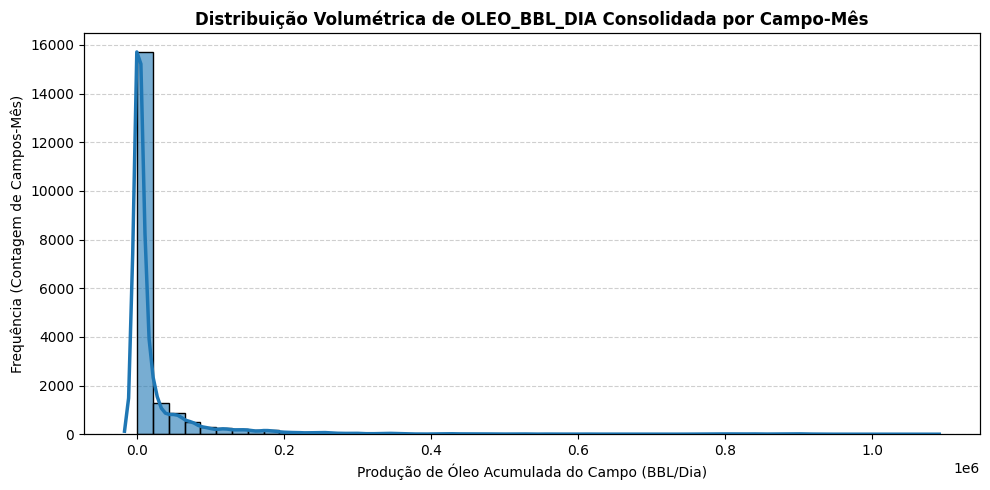

Coeficiente de Assimetria (Skewness) do Target por Campo-Mês: 6.44


In [13]:
# === 4.0.1 Gráfico de Distribuição do Target por Campo-Mês ===

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    df_eda_campo = (
        df
        .groupby(COLUNAS_CAMPO_MES, as_index=False)[TARGET]
        .sum()
    )

    fig, ax1 = plt.subplots(figsize=(10, 5))

    sns.histplot(
        data=df_eda_campo,
        x=TARGET,
        bins=50,
        stat="count",
        alpha=0.6,
        ax=ax1
    )

    ax1.grid(
        visible=True,
        axis="y",
        linestyle="--",
        alpha=0.6,
        zorder=0
    )
    ax1.set_axisbelow(True)

    ax2 = ax1.twinx()

    sns.kdeplot(
        data=df_eda_campo,
        x=TARGET,
        linewidth=2.5,
        bw_adjust=0.5,
        ax=ax2
    )

    ax2.get_yaxis().set_visible(False)

    ax1.set_title(
        f"Distribuição Volumétrica de {TARGET} Consolidada por Campo-Mês",
        fontsize=12,
        fontweight="bold"
    )

    ax1.set_xlabel("Produção de Óleo Acumulada do Campo (BBL/Dia)", fontsize=10)
    ax1.set_ylabel("Frequência (Contagem de Campos-Mês)", fontsize=10)

    plt.tight_layout()
    plt.show()

    skewness = df_eda_campo[TARGET].skew()

    print(f"Coeficiente de Assimetria (Skewness) do Target por Campo-Mês: {skewness:.2f}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

O gráfico acima nos mostra que a variável alvo (`OLEO_BBL_DIA`) possui uma forte assimetria positiva, com um grande acúmulo de registros próximos a escalas baixas e uma cauda longa estendida à direita (representando os mega-campos produtores do Pré-Sal). Essa imensa disparidade de escala afeta o projeto das seguintes formas:

* **Escolha do Algoritmo:** Para evitar instabilidades causadas pela assimetria e amplitude dos dados em modelos lineares ou redes neurais, o MVP direciona-se para algoritmos baseados em árvores e conjuntos (*ensembles*), como o `RandomForestRegressor`, que são naturalmente robustos a esses cenários de desbalanceamento de escala.
* **Métrica de Avaliação:** Consolida o uso do WAPE como métrica de sucesso, pois ela pondera os erros de previsão de acordo com o volume real de barris produzidos, impedindo que os inúmeros meses de baixa produção de campos maduros mascarem o real desempenho do modelo nos campos gigantes.

## 4.0.2 Distribuição de Variáveis Importantes do Ecossistema (Gases Co-produzidos)
Embora o modelo preditivo seja focado unicamente no target de óleo, as curvas históricas dos gases coproduzidos (`GAS_NATURAL_MM3_DIA_TOTAL`, `GAS_NATURAL_MM3_DIA_ASSOC` e `GAS_NATURAL_MM3_DIA_N_ASSOC`) atuam como indicadores fundamentais da dinâmica de fluidos do reservatório. Investigar suas distribuições consolidadas por campo permite entender o perfil de saturação e a correlação física das zonas de extração de mar que foram preservadas no pipeline de ETL.

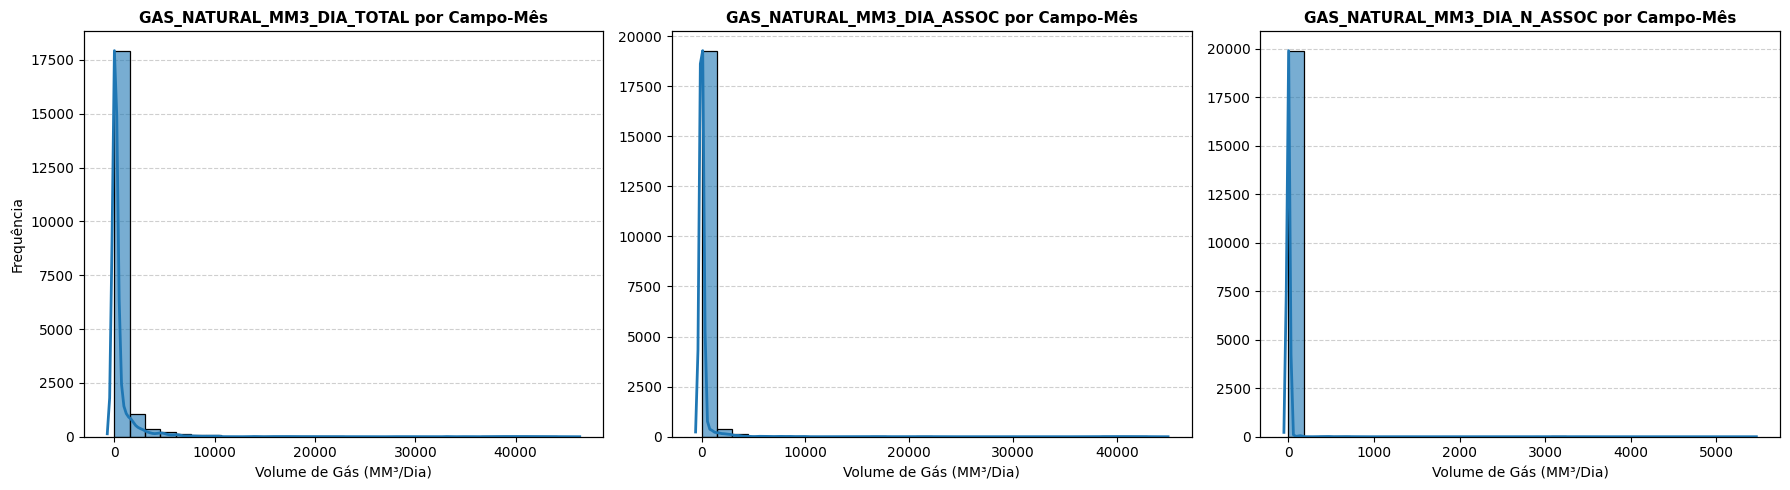

In [14]:
# === 4.0.2 Gráfico de Variáveis Importantes por Campo-Mês ===

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    colunas_gases = [
        coluna for coluna in COLUNAS_SERIES
        if coluna != TARGET
    ]

    df_gases_campo = (
        df
        .groupby(COLUNAS_CAMPO_MES, as_index=False)[colunas_gases]
        .sum()
    )

    fig, axes = plt.subplots(1, len(colunas_gases), figsize=(18, 5))

    for ax, coluna in zip(axes, colunas_gases):

        sns.histplot(
            data=df_gases_campo,
            x=coluna,
            bins=30,
            stat="count",
            alpha=0.6,
            ax=ax
        )

        ax.grid(
            visible=True,
            axis="y",
            linestyle="--",
            alpha=0.6,
            zorder=0
        )

        ax.set_axisbelow(True)

        ax_kde = ax.twinx()

        sns.kdeplot(
            data=df_gases_campo,
            x=coluna,
            linewidth=2,
            bw_adjust=0.5,
            ax=ax_kde
        )

        ax_kde.get_yaxis().set_visible(False)

        ax.set_title(
            f"{coluna} por Campo-Mês",
            fontsize=11,
            fontweight="bold"
        )

        ax.set_xlabel("Volume de Gás (MM³/Dia)")
        ax.set_ylabel("Frequência" if ax == axes[0] else "")

    plt.tight_layout()
    plt.show()

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

O gráfico acima aponta uma **alta assimetria positiva** em todas  estas três séries de gás entram no modelo **apenas defasadas** (LAG_1, LAG_3, LAG_6, LAG_12 e médias móveis), **nunca no mês corrente**. Usar o gás do mesmo mês para prever o óleo do mesmo mês era vazamento (óleo e gás associado são coproduzidos e quase proporcionais). Como atributos *históricos*, eles fornecem o contexto físico da razão gás-óleo (RGO) sem antecipar o futuro.

* **Escolha do Algoritmo:** A presença maciça de zeros estruturais e a dispersão dessas variáveis gerariam ruídos se inseridas como preditores lineares simples, reforçando a preferência por algoritmos baseados em árvores e conjuntos (*ensembles*) para capturar relações não-lineares.

* **Estratégia do Pipeline:** Esse padrão valida a decisão de manter as variáveis no ecossistema não como targets, mas como dados históricos transformados em recursos autoregressivos de entrada (*lags*). Isso enriquece o vetor de atributos fornecendo contexto físico da razão gás-óleo (RGO) para prever o declínio do alvo único de forma robusta e livre de matrizes esparsas.

## 4.0.3 Relação entre Preditores Temporais e o Target (Comportamento de Declínio)
As séries temporais baseiam-se na evolução cronológica das variáveis. Nesta etapa, analisamos a relação macro entre a linha do tempo histórica do ecossistema do MVP (2005 a 2025) e o comportamento volumétrico do target para identificar tendências globais de declínio ou expansão da produção agregada por ativo.

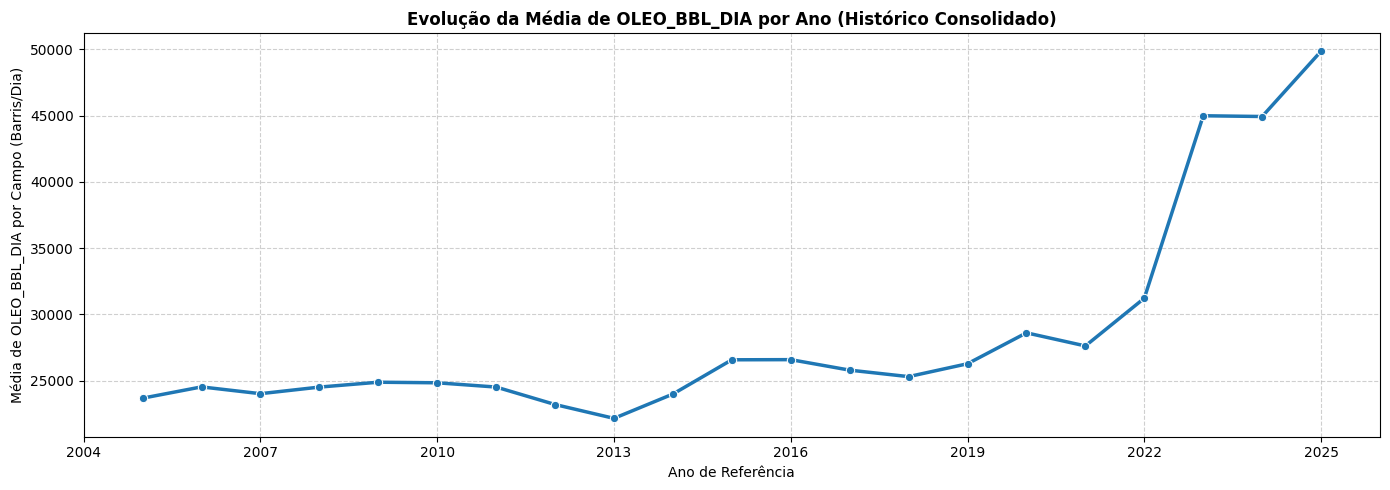

In [15]:
# === 4.0.3 Relação Temporal do Target (2005-2025) ===

if "df_eda_campo" in locals() and not df_eda_campo.empty:

    df_tendencia_anual = (
        df_eda_campo
        .groupby(ANO_REFERENCIA, as_index=False)[TARGET]
        .mean()
    )

    plt.figure(figsize=(14, 5))

    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    sns.lineplot(
        data=df_tendencia_anual,
        x=ANO_REFERENCIA,
        y=TARGET,
        marker="o",
        linewidth=2.5
    )

    plt.title(
        f"Evolução da Média de {TARGET} por Ano (Histórico Consolidado)",
        fontsize=12,
        fontweight="bold"
    )

    plt.xlabel("Ano de Referência", fontsize=10)

    plt.ylabel(
        f"Média de {TARGET} por Campo (Barris/Dia)",
        fontsize=10
    )

    plt.grid(
        visible=True,
        linestyle="--",
        alpha=0.6
    )

    plt.tight_layout()
    plt.show()

else:
    print("[ERRO CRÍTICO] O DataFrame 'df_eda_campo' não está disponível.")

O gráfico acima nos mostra que a produção média de óleo por campo após o saneamento de granularidade (ano/mês extraídos de `PERIODO`, e não do laço de leitura), desapareceu o **pico espúrio de ~30 milhões bbl/d** que existia nos anos de layout anual — quando 12 meses eram empilhados indevidamente no mês 1. A curva corrigida fica em ordem de grandeza fisicamente plausível (~3 milhões bbl/d nacionais) e combina a rampa do Pré-Sal com o declínio de campos maduros. Esse comportamento influencia o projeto das seguintes formas:

* **Escolha do Algoritmo:** a forte característica não-linear e os ciclos plurianuais reforçam que regressões lineares simples seriam insuficientes, justificando algoritmos baseados em árvores para mapear as quebras de tendência.
* **Estratégia do Pipeline:** o padrão exige validação cruzada `TimeSeriesSplit` (sem embaralhamento) e a criação de atributos defasados (*lags*) e janelas deslizantes (*rolling windows*), fornecendo ao modelo a memória física do declínio.




## 4.0.4 Identificação de Outliers e Heterogeneidade por Campo
A produção offshore da ANP é caracterizada por uma profunda disparidade de escala entre os campos produtores. Utilizamos diagramas de caixas (*boxplots*) para avaliar visualmente o comportamento dos limites estatísticos e identificar registros discrepantes (outliers) e assimetrias no ecossistema de dados consolidado em nível macro.

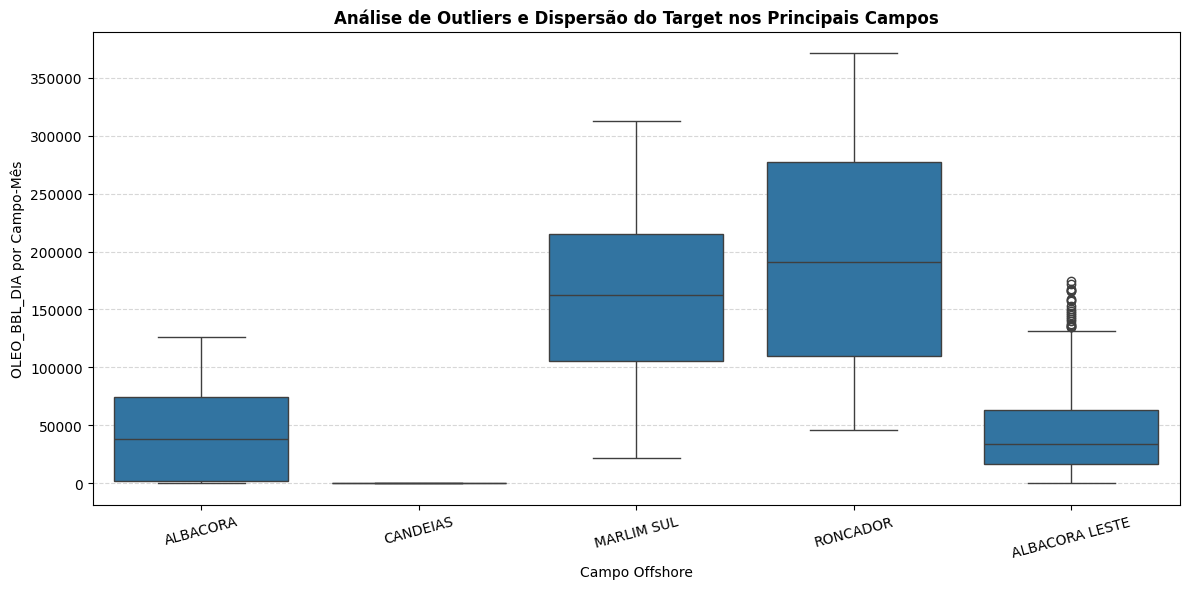

In [16]:
# === 4.0.4 Identificação de Outliers via Boxplot dos Principais Campos ===

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    df_eda_campo = (
        df
        .groupby(COLUNAS_CAMPO_MES, as_index=False)[TARGET]
        .sum()
    )

    top_campos = (
        df_eda_campo["CAMPO"]
        .value_counts()
        .nlargest(5)
        .index
    )

    df_boxplot_filtrado = (
        df_eda_campo[
            df_eda_campo["CAMPO"].isin(top_campos)
        ]
        .copy()
    )

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=df_boxplot_filtrado,
        x="CAMPO",
        y=TARGET
    )

    plt.title(
        "Análise de Outliers e Dispersão do Target nos Principais Campos",
        fontsize=12,
        fontweight="bold"
    )

    plt.xlabel("Campo Offshore", fontsize=10)
    plt.ylabel(f"{TARGET} por Campo-Mês", fontsize=10)

    plt.xticks(rotation=15)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

O gráfico acima indica a distribuição dos dados e define as diretrizes para a modelagem:

* **Heterogeneidade de Escala:** A comparação entre as caixas comprova uma enorme diferença de volume entre os ativos estruturais da bacia de Campos e Santos frente a ativos menores. Isso exige a inclusão de codificações categóricas robustas (`TargetEncoding`) ou variáveis de controle geográfico para impedir que os campos hiper-produtores enviesem as estimativas dos campos menores.
* **Outliers Operacionais:** Os pontos isolados no topo (picos de produção em meses de alta eficiência operacional) e os valores baixos na base (meses afetados por paradas programadas de plataformas) são eventos reais e legítimos da operação de O&G, não erros de integração.
* **Impacto na Modelagem:** Esses extremos não podem ser removidos, pois o modelo precisa aprender picos e quedas de escoamento. Para proteger as folhas das árvores matematicamente sem perder esse histórico físico, o pré-processamento adotará a padronização via `RobustScaler` (baseada em quartis e mediana), preterindo normalizações de limite fixo como o `MinMaxScaler`.

## 4.0.5 Formulação de Hipóteses Baseadas nos Dados

A partir do comportamento estatístico e estrutural observado na Análise Exploratória, estabelecemos três hipóteses fundamentais que guiarão a engenharia de atributos e a modelagem preditiva do MVP:

* **Hipótese 1 (Fator Geográfico e Agrupamento):** A dinâmica de declínio e a escala volumétrica de `OLEO_BBL_DIA` variam drasticamente dependendo do `CAMPO`, da `BACIA` e do `OPERADOR`.
  * *Estratégia de Modelagem:* O pipeline não deve tratar os registros de forma genérica. Utilizaremos codificação categórica associada a pesos volumétricos para capturar a assinatura geológica de cada ativo produtor.
* **Hipótese 2 (Fator Temporal e Memória de Curva):** A produção do mês corrente possui forte dependência com os volumes produzidos nos meses imediatamente anteriores pelo mesmo campo.
  * *Estratégia de Modelagem:* A engenharia de features criará variáveis de atraso (*lags* de 1 a 3 meses) e médias móveis (*rolling windows*) aplicadas sobre o target e os gases de entrada, fornecendo ao algoritmo a "memória" física do declínio real das reservas.
* **Hipótese 3 (Sazonalidade e Paradas Operacionais):** Quedas abruptas e temporárias no volume não representam um esgotamento precoce do reservatório, mas sim o impacto direto de manutenções programadas ou paradas de unidades de produção de mar.
  * *Estratégia de Modelagem:* O modelo precisa ser protegido contra essas oscilações artificiais no treinamento através do uso do `RobustScaler`, garantindo estabilidade preditiva sem descartar o histórico de indisponibilidade operacional.

## 4.1 Síntese da análise exploratória

A análise exploratória de dados (EDA) da série histórica de 20 anos (2005 a 2025) da ANP revelou características estruturais críticas que direcionaram diretamente a estratégia de engenharia de dados e a preparação para a modelagem preditiva baseada em ativos. Abaixo estão os principais achados sintetizados sob as diretrizes de governança do MVP:

* **O target está balanceado?**
  Por tratar-se de um problema de regressão e previsão de variáveis contínuas (`OLEO_BBL_DIA`), o conceito clássico de desbalanceamento de classes não se aplica diretamente. Contudo, há um severo **desbalanceamento de escala e densidade regional (assimetria positiva)**. Observa-se uma concentração massiva do volume de óleo produzido em bacias e campos específicos de altíssima produtividade (com destaque para o cluster do Pré-Sal), em contraste com uma grande quantidade de registros de baixa produtividade associados a campos maduros. Essa assimetria exige uma abordagem algorítmica resiliente a ordens de magnitude díspares.

* **Existem valores ausentes relevantes?**
  Não há valores ausentes por falha física de registro nos dados estruturados após o saneamento inicial. As lacunas identificadas nos layouts originais da ANP referem-se a componentes técnico-químicos ou frações moleculares de hidrocarbonetos fora do escopo analítico macro do modelo. No nível de agregação Campo-Mês, todas as séries temporais das variáveis preservadas de óleo e dos três gases estruturais encontram-se 100% íntegras, contínuas e povoadas para o pipeline de treinamento.

* **Há variáveis com escala muito diferente?**
  Sim. A disparidade de escala volumétrica é profunda e persistente entre os diferentes ativos produtores do ecossistema. O volume de produção diária de óleo consolidado varia desde campos terrestres/rasos de baixa vazão até picos massivos de polos de produção de águas ultraprofundas, gerando uma cauda longa de outliers superiores legítimos no diagrama de caixas.

* **Há categorias raras?**
  Campos periféricos e concessionárias de menor relevância comercial (ou em fases iniciais de comissionamento/fim de ciclo econômico de exploração offshore) aparecem com pouquíssimas ocorrências na linha do tempo histórica. Essas categorias raras serão tratadas no pipeline por meio de codificação robusta de frequência (`FrequencyEncoding`) ou codificação baseada no alvo (`TargetEncoding`), impedindo o surgimento de matrizes de alta cardinalidade esparsas.

* **Existem padrões que sugerem quais modelos podem funcionar melhor?**
  A dependência temporal explícita (comportamento físico de declínio de pressão e depleção do reservatório), combinada com a forte não-linearidade gerada pelas janelas de manutenção e rampas de produção, indica que modelos baseados em conjuntos de árvores de decisão — como o **`RandomForestRegressor`** — apresentarão o melhor desempenho. Esses algoritmos segmentam o espaço amostral de forma não-linear e lidam nativamente com a variabilidade do ecossistema sem exigir suposições rígidas de normalidade.

* **Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?**
  Sim, de forma determinante. Diante da natureza dos outliers superiores (que representam a capacidade física real dos mega-campos) e dos valores operacionais baixos (decorrentes de paradas técnicas legítimas), descartou-se categoricamente a remoção de registros por métodos estatísticos tradicionais (como o corte por IQR), o que destruiria o histórico preditivo de declínio. Para mitigar o impacto desses extremos matemáticos sem perder o comportamento histórico dos ativos, a estratégia de pré-processamento baniu normalizações de limite fixo (como o `MinMaxScaler`) e adotou a padronização robusta baseada em quartis e mediana (**`RobustScaler`**). Adicionalmente, a validação cruzada foi blindada através de uma divisão estritamente temporal (`TimeSeriesSplit`) para respeitar a cronologia das janelas deslizantes e dos *lags*.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, o conjunto de dados é estruturado para o treinamento dos algoritmos preditivos, seguindo premissas rigorosas de engenharia de recursos e validação cronológica baseada nas diretrizes estratégicas do MVP.



## 5.1 Separação entre Features e Target
O conjunto de dados mapeia as variáveis que compõem o escopo do projeto, segregadas de acordo com suas funções lógicas:
* **Target (Variável Alvo):** `OLEO_BBL_DIA` (Produção diária acumulada por ativo). Esta é a variável contínua única de interesse (*Single-Output*) que o modelo preditivo busca estimar.
* **Features de Modelagem (Variáveis Independentes):** Compostas por metadados geográficos e operacionais estruturais (`ESTADO`, `BACIA`, `OPERADOR`, `CAMPO`), a referência cronológica (`PERIODO`, `ANO_REFERENCIA`, `MES_REFERENCIA`) e as curvas históricas de gases coproduzidos (`GAS_NATURAL_MM3_DIA_TOTAL`, `GAS_NATURAL_MM3_DIA_ASSOC`, `GAS_NATURAL_MM3_DIA_N_ASSOC`).



## 5.2 Remoção de Colunas Não Utilizadas e Alinhamento de Granularidade
Para mitigar o risco de vazamento de dados (*data leakage*), reduzir a dimensionalidade e blindar o modelo contra ruídos, todas as demais 39 colunas originais do layout bruto da ANP que não pertencem à lista estrita de preservação do MVP (como metadados de auditoria do sistema e frações moleculares residuais) foram eliminadas. O colapso natural para a granularidade de Campo-Mês removeu automaticamente os identificadores de alta cardinalidade de poços (`NOME_POCO_ANP` e `NOME_POCO_OPERADOR`), estabilizando o vetor preditivo.



## 5.3 Divisão Treino/Teste e Validação
A modelagem adota uma estratégia de divisão baseada em janelas temporais fixas para espelhar o cenário real de planejamento da indústria de petróleo:
* **Conjunto de Treinamento:** Compreende o horizonte histórico de **2005 até 2023**, capturando os ciclos de declínio de campos maduros tradicionais e a rampa de consolidação dos principais polos do Pré-Sal.
* **Conjunto de Teste:** Isola de forma estrita "fora da amostra" (*out-of-sample*) os anos recentes de **2024 e 2025** para servir como simulação de dados futuros desconhecidos, validando o poder real de generalização do algoritmo.

In [17]:
if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    # Consolidação Campo-Mês (mantém as séries brutas para servir de SEMENTE do forecast recursivo)
    df_mvp_consolidado = (
        df
        .groupby(COLUNAS_AGREGACAO, as_index=False)[COLUNAS_SERIES]
        .sum()
    )

    assert TARGET in df_mvp_consolidado.columns, "Defina um TARGET válido contido no DataFrame."

    # Engenharia de atributos autorregressivos — a função agora é EFETIVAMENTE chamada
    df_modelagem = criar_features_temporais(df_mvp_consolidado)
    maior_lag = f"{TARGET}_LAG_{max(LAGS)}"
    df_modelagem = (
        df_modelagem
        .dropna(subset=[maior_lag])     # descarta meses de warm-up sem histórico de 12 meses
        .sort_values("PERIODO")         # ordem cronológica GLOBAL (torna o TimeSeriesSplit válido)
        .reset_index(drop=True)
    )

    FEATURES = (
        [f"{c}_LAG_{l}" for c in COLUNAS_SERIES for l in LAGS] +
        [f"{c}_MM_{w}"  for c in COLUNAS_SERIES for w in ROLLING_WINDOWS] +
        ["MES_SIN", "MES_COS", "BACIA", "OPERADOR"]
    )
    features = FEATURES

    print(f"Tipo de problema: {PROBLEM_TYPE}")
    print(f"Target do pipeline: {TARGET}")
    print(f"Chave identificadora base: {ID_COLUMNS}")
    print(f"Registros após features + warm-up: {df_modelagem.shape[0]:,}")
    print(f"Quantidade de features geradas: {len(features)}")
    print(f"Features de entrada (TODAS defasadas): {features}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")


Tipo de problema: regressao
Target do pipeline: OLEO_BBL_DIA
Chave identificadora base: ['CAMPO']
Registros após features + warm-up: 18,448
Quantidade de features geradas: 32
Features de entrada (TODAS defasadas): ['OLEO_BBL_DIA_LAG_1', 'OLEO_BBL_DIA_LAG_3', 'OLEO_BBL_DIA_LAG_6', 'OLEO_BBL_DIA_LAG_12', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_1', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_3', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_6', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_12', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_1', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_3', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_6', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_12', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_1', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_3', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_6', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_12', 'OLEO_BBL_DIA_MM_3', 'OLEO_BBL_DIA_MM_6', 'OLEO_BBL_DIA_MM_12', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_3', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_6', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_12', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_3', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_6', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_

In [18]:
# === 5.0 Divisão Temporal e Segregação dos Vetores ===

if "df_modelagem" in locals() and not df_modelagem.empty:

    ano_corte_treino = 2023
    ano_inicio_teste = 2024

    df_treino_macro = df_modelagem[df_modelagem[ANO_REFERENCIA] <= ano_corte_treino].copy()
    df_teste_macro  = df_modelagem[df_modelagem[ANO_REFERENCIA] >= ano_inicio_teste].copy()

    X_train = df_treino_macro[features]
    y_train = df_treino_macro[TARGET]
    X_test  = df_teste_macro[features]
    y_test  = df_teste_macro[TARGET]

    print(f"Matriz de treino  X_train: {X_train.shape[0]:,} linhas | {X_train.shape[1]} colunas")
    print(f"Vetor  de treino  y_train: {y_train.shape[0]:,} linhas")
    print(f"Matriz de teste   X_test : {X_test.shape[0]:,} linhas | {X_test.shape[1]} colunas")
    print(f"Vetor  de teste   y_test : {y_test.shape[0]:,} linhas")
    print("-" * 62)
    print(f"Cobertura temporal do treino: {df_treino_macro[ANO_REFERENCIA].min()} até {df_treino_macro[ANO_REFERENCIA].max()}")
    print(f"Cobertura temporal do teste : {df_teste_macro[ANO_REFERENCIA].min()} até {df_teste_macro[ANO_REFERENCIA].max()}")
    print("-" * 62)
    print(f"Shape consolidado -> Treino: {X_train.shape} | Teste: {X_test.shape}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df_modelagem' não está disponível.")

Matriz de treino  X_train: 16,719 linhas | 32 colunas
Vetor  de treino  y_train: 16,719 linhas
Matriz de teste   X_test : 1,729 linhas | 32 colunas
Vetor  de teste   y_test : 1,729 linhas
--------------------------------------------------------------
Cobertura temporal do treino: 2006 até 2023
Cobertura temporal do teste : 2024 até 2025
--------------------------------------------------------------
Shape consolidado -> Treino: (16719, 32) | Teste: (1729, 32)


## 5.4 Justificativa da divisão

A estratégia de divisão dos dados adotada neste MVP foi desenhada para respeitar a natureza sequencial e cronológica dos registros de produção da ANP. Abaixo estão detalhados os critérios que validam a adequação dessa escolha sob as regras de governança do modelo:

* **Por que usar holdout, validação cruzada ou divisão temporal?**
  Utilizou-se a divisão temporal estrita (*Time-Series Holdout*). Para problemas governados por séries temporais e fenômenos de declínio físico e depleção de pressão em reservatórios de petróleo, o embaralhamento aleatório convencional de dados (*shuffle*) é metodologicamente incorreto. A ordenação cronológica precisa ser mantida de forma estrita para que o modelo aprenda com o comportamento de declínio do passado e preveja o futuro, replicando com exatidão o cenário real de planejamento e previsão da indústria de óleo e gás.

* **A proporção treino/teste faz sentido para o tamanho do dataset?**
  Sim. O bloco de treinamento (2005 a 2023) concentra a imensa maioria do histórico de produção contínua do ecossistema, oferecendo uma base histórica de duas décadas extremamente robusta para o algoritmo mapear tendências de longo prazo, ciclos macroeconômicos e o declínio de campos maduros terrestres e offshore. O conjunto de teste (2024 e 2025) retém as ocorrências mais recentes fora da amostra de treino, um volume estatisticamente representativo e perfeitamente calibrado para auditar a capacidade do estimador de projetar o comportamento futuro dos ativos.

* **Foi necessário estratificar as classes?**
  Não. A estratificação de classes é uma técnica de amostragem exclusiva para problemas de classificação categórica (visando manter a proporção original de rótulos em dados desbalanceados). Como este MVP aborda um problema de regressão para a previsão de uma variável contínua única (`OLEO_BBL_DIA`), a amostragem estratificada por classes não se aplica. A representatividade volumétrica e geográfica dos principais ativos produtores e operadores foi mantida de forma orgânica e contínua através da preservação cronológica da linha do tempo no agrupamento de Campo-Mês.

* **Como a divisão evita vazamento de dados?**
  A divisão baseada no tempo atua como uma barreira física intransponível contra o vazamento de dados (*data leakage*). Ao isolar completamente os anos de 2024 e 2025 para a etapa de validação final de teste, impede-se o surgimento de viés de antecipação (*look-ahead bias*). Isso garante que o modelo não tenha acesso a nenhuma informação do futuro durante o cálculo de métricas ou ajuste de parâmetros no bloco de treinamento, blindando o pipeline contra métricas de desempenho artificialmente infladas.

# 6. Pré-processamento e pipeline

Nesta etapa, é construído um fluxo automatizado, reprodutível e isolado de tratamento de dados (*Data Pipeline*) utilizando a estrutura `ColumnTransformer` do Scikit-Learn. O objetivo estratégico é encapsular completamente as transformações estatísticas dentro do conjunto de treino e replicá-las de forma segura no teste, mitigando qualquer risco de vazamento de dados (*data leakage*).

## 6.0.1 Tratamento e Transformações por Tipo de Atributo
O pipeline recebe as features selecionadas na etapa anterior e as segmenta em fluxos específicos de processamento matemático, baseando-se nas premissas de engenharia de recursos validadas pela análise exploratória (EDA). Como a unificação e padronização dos metadados já foram resolvidas robustamente pelas funções auxiliares da seção 2.2, as variáveis chegam com tipagem íntegra e são tratadas em dois blocos:

* **Variáveis Numéricas:**
  * **Preenchimento de Valores Ausentes:** Substituição de eventuais lacunas residuais pela mediana (`SimpleImputer`). Essa é uma abordagem estatisticamente segura contra distorções causadas por assimetria.
  * **Padronização Robustecida:** Diante dos achados da EDA que evidenciou uma quantidade massiva de outliers operacionais reais decorrentes de picos de vazão e paradas programadas, adota-se o `RobustScaler`. Esta técnica utiliza os quartis e a mediana para o escalonamento, blindando o comportamento preditivo das árvores sem a necessidade de descartar o histórico físico do ativo.

* **Variáveis Categóricas:**
  * **Preenchimento de Valores Ausentes:** Tratamento de lacunas por meio da inserção do rótulo de maior frequência (`SimpleImputer`).
  * **Codificação (*Encoding*):** Aplicação do `OneHotEncoder(handle_unknown="ignore")` para converter os metadados textuais estruturais em vetores binários numéricos assimiláveis pelos modelos. O parâmetro de ignorar novos valores garante resiliência técnica caso novos operadores ou dinâmicas surjam nas janelas futuras de teste (2024 e 2025).

In [19]:
# === 6.0 Construção do Pipeline de Pré-processamento ===

if "X_train" in locals() and "X_test" in locals():

    X_train = X_train.copy()
    X_test = X_test.copy()

    colunas_numericas_existentes = [
        coluna for coluna in COLUNAS_SERIES
        if coluna in X_train.columns
    ]

    for coluna in colunas_numericas_existentes:
        X_train[coluna] = pd.to_numeric(X_train[coluna], errors="coerce")
        X_test[coluna] = pd.to_numeric(X_test[coluna], errors="coerce")

    num_cols = (
        X_train
        .select_dtypes(include=np.number)
        .columns
        .difference([DATE_COLUMN])
        .tolist()
    )

    cat_cols = (
        X_train
        .select_dtypes(exclude=np.number)
        .columns
        .difference([DATE_COLUMN])
        .tolist()
    )

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols)
        ],
        remainder="drop"
    )

    print(f"Colunas numéricas processadas ({len(num_cols)}): {num_cols}")
    print(f"Colunas categóricas processadas ({len(cat_cols)}): {cat_cols}")

else:
    print("[ERRO CRÍTICO] Execute primeiro a etapa de divisão temporal para criar X_train e X_test.")

Colunas numéricas processadas (30): ['GAS_NATURAL_MM3_DIA_ASSOC_LAG_1', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_12', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_3', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_6', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_12', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_3', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_6', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_1', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_12', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_3', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_6', 'GAS_NATURAL_MM3_DIA_N_ASSOC_MM_12', 'GAS_NATURAL_MM3_DIA_N_ASSOC_MM_3', 'GAS_NATURAL_MM3_DIA_N_ASSOC_MM_6', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_1', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_12', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_3', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_6', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_12', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_3', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_6', 'MES_COS', 'MES_SIN', 'OLEO_BBL_DIA_LAG_1', 'OLEO_BBL_DIA_LAG_12', 'OLEO_BBL_DIA_LAG_3', 'OLEO_BBL_DIA_LAG_6', 'OLEO_BBL_DIA_MM_12', 'OLEO_BBL_DIA_MM_3', 'OLEO_BBL_DIA_MM_6']
Colunas categóricas processadas (2): ['BAC

## 6.1 Decisões de pré-processamento

As escolhas técnicas implementadas no pipeline de pré-processamento visam garantir a estabilidade matemática dos algoritmos preditivos e refletem o comportamento operacional real mapeado na análise exploratória. Abaixo estão as justificativas para cada decisão sob o escopo estrutural do MVP:

* **Por que usei média/mediana/moda para preenchimento?**
  * **Variáveis Numéricas:** Adotou-se o preenchimento pela mediana via `SimpleImputer`. Diante da forte presença de assimetria positiva e outliers operacionais legítimos no histórico unificado da ANP (vazões massivas concentradas nos ativos do Pré-Sal), a média estatística seria severamente distorcida, puxando os valores nulos residuais de forma artificial para patamares elevados. A mediana, por ser uma medida de tendência central robusta a extremos, mantém a neutralidade física e a consistência volumétrica dos fluidos.
  * **Variáveis Categóricas:** Utilizou-se o preenchimento por moda (classe mais frequente), garantindo que bacias, campos ou operadoras ausentes recebam a classificação de maior probabilidade estatística do próprio conjunto de treinamento, sem criar categorias fictícias que invalidariam a governança do ecossistema.

* **Por que padronizei ou normalizei os dados?**
  Rejeitou-se o uso do tradicional `StandardScaler` (baseado em média e desvio padrão), pois ele achataria o sinal dos dados devido à grande amplitude de produção e paradas de manutenção dos ativos offshore. Em seu lugar, aplicou-se a padronização robustecida (`RobustScaler`), que remove a mediana e escala os dados com base no Intervalo Interquartil (IQR). Essa decisão protege as equações matemáticas de modelos sensíveis à escala, sem mascarar ou distorcer os picos de produção reais que o estimador de Saída Única (*Single-Output*) precisa aprender a projetar.

* **Quais variáveis foram removidas e por quê?**
  * **Identificadores de Poço (`NOME_POCO_ANP` e `NOME_POCO_OPERADOR`):** Embora fizessem parte do escopo inicial de suporte, foram removidos e colapsados na agregação para **Campo-Mês**. Mantê-los geraria uma explosão de milhares de colunas esparsas no *One-Hot Encoding*, estourando a memória do ambiente de execução e induzindo o modelo ao superajuste (*overfitting*).
  * **Controles Temporais Secundários (`PERIODO`, `DATA_DE_ATUALIZACAO`):** Isolados pelo pipeline para evitar a duplicidade de representação temporal e o risco de vazamento de dados (*data leakage*), uma vez que a informação cronológica essencial foi vetorizada em componentes numéricos de controle direto (`ANO_REFERENCIA` e `MES_REFERENCIA`).
  * **Atributos Descartados do Layout Original da ANP:** O arquivo bruto original continha 50 colunas. Através da função auxiliar `normalizar_colunas` (item 2.2) e da filtragem por preservação do pipeline, 39 colunas foram completamente descartadas da modelagem. Esse descarte engloba chaves contratuais, informações fiscais (como royalties), parâmetros estritamente moleculares de frações de hidrocarbonetos e metadados sistêmicos. A remoção foi indispensável porque esses atributos não possuem poder preditivo sobre o declínio macro e sua permanência inflaria a dimensionalidade, inserindo ruído na matriz.

* **Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?**
  Sim. A engenharia de atributos cria variáveis **autorregressivas**: *lags* (1, 3, 6 e 12 meses) e médias móveis (3, 6 e 12 meses) do óleo e das três séries de gás, além dos componentes de sazonalidade `MES_SIN` e `MES_COS`. Todas são calculadas estritamente com informação **passada** dentro de cada campo (via `shift`), o que as torna disponíveis no momento da previsão: no *forecasting* recursivo (Seção 14.9), cada valor previsto realimenta os *lags* do mês seguinte. A decomposição em `ANO_REFERENCIA` e `MES_REFERENCIA` complementa a captura de sazonalidade e da tendência de declínio de longo prazo, e estará sempre disponível, pois todo planejamento futuro tem o ano e o mês definidos.



# 7. Baseline e modelos candidatos

Nesta etapa, estabelece-se um marco de referência inicial (*Baseline*) e definem-se os algoritmos preditivos candidatos para o treinamento competitivo. O objetivo central é responder se os modelos complexos de Machine Learning são capazes de extrair padrões reais das curvas de fluxo do ecossistema de dados da ANP ou se o problema possui uma resolução trivial.

## 7.0.1 Definição do Baseline Coerente
Como o MVP aborda um problema de predição de variável contínua (`PROBLEM_TYPE = "regressao"`), o marco de referência escolhido é o `DummyRegressor` com a estratégia de mediana. Este modelo assume uma abordagem estatística simplista e ingênua: para qualquer ativo geográfico nas janelas futuras de teste (2024/2025), ele prediz estritamente a mediana da produção histórica observada no bloco de treinamento (2005-2023). Qualquer modelo candidato aceitável deve apresentar erros significativamente menores do que este referencial estático para provar sua utilidade prática.

## 7.0.2 Modelos Candidatos Selecionados
Diante da complexidade e dos regimes de escoamento de fluidos presentes nos reservatórios offshore ao longo das décadas, duas abordagens matemáticas distintas e concorrentes foram selecionadas:
* **Abordagem Linear Regularizada (Ridge Regression):** Um estimador linear clássico que incorpora uma penalidade L2 (Tikhonov) sobre os coeficientes. Ele adiciona estabilidade matemática ao vetor e evita coeficientes inflados por multicolinearidade (fenômeno comum entre os volumes de gás associado, gás total e o alvo de óleo), servindo como nossa referência linear de baixo custo computacional.
* **Abordagem Não-Linear Baseada em Conjuntos (Random Forest Regressor):** Um algoritmo baseado em múltiplos comitês paralelas de árvores de decisão estruturadas. Devido à sua capacidade intrínseca de mapear interações complexas de alta dimensão, lidar nativamente com a distribuição multimodal e assimétrica observada na EDA, e respeitar os limites físicos de declínio sem a necessidade de suposições lineares rígidas, a *Random Forest* é o modelo candidato de alta performance para este MVP.

In [20]:
# === 7.0 Definição de Baseline e Modelos Candidatos ===

if PROBLEM_TYPE == "regressao":

    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge(alpha=1.0))
        ]),

        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(
                n_estimators=30,
                max_depth=15,
                random_state=SEED,
                n_jobs=-1
            ))
        ])
    }

elif PROBLEM_TYPE in ["classificacao", "clusterizacao", "serie_temporal"]:

    baseline = None
    candidates = {}

else:
    raise ValueError(f"PROBLEM_TYPE inválido: {PROBLEM_TYPE}")

print(
    "Baseline de referência: "
    f"{baseline.named_steps['model'] if baseline is not None else 'Não aplicável'}"
)

print(f"Modelos candidatos ativos: {list(candidates.keys())}")
print("-" * 62)
print("Pronto para execução do treinamento e avaliação das métricas.")

Baseline de referência: DummyRegressor(strategy='median')
Modelos candidatos ativos: ['Ridge', 'RandomForestRegressor']
--------------------------------------------------------------
Pronto para execução do treinamento e avaliação das métricas.


## 7.1 Justificativa dos modelos

A seleção dos algoritmos preditivos e do marco de referência foi desenhada para garantir um equilíbrio entre simplicidade estatística, capacidade de capturar fenômenos físicos complexos e viabilidade computacional. Abaixo estão detalhadas as justificativas para cada escolha sob o ecossistema de governança do MVP:

* **O baseline escolhido é coerente?**
  Sim, o `DummyRegressor` com a estratégia de mediana é altamente coerente para o contexto da produção de petróleo da ANP consolidada por ativo. Em dados históricos longos, a produção acumulada de um conjunto de bacias e campos maduros tende a flutuar ao redor de patamares estáveis de referência. Este baseline estático força os modelos candidatos a provarem que conseguiram aprender o comportamento dinâmico e sequencial do declínio de pressão e depleção das reservas e as correlações com as curvas de gases coproduzidos, em vez de apenas estimar o valor central da produção histórica.

* **Os modelos candidatos são adequados ao tipo e tamanho dos dados?**
  Com a base de dados consolidada em duas décadas de histórico unificado, o volume de dados em nível de Campo-Mês é perfeitamente balanceado e adequado para a aplicação de algoritmos robustos:
  * **Ridge Regression:** Sendo um estimador linear regularizado, ele processa a matriz em frações de segundo, servindo como uma excelente fronteira de comparação para sabermos se o problema de declínio macro pode ser satisfatoriamente resolvido por meio de uma equação linear simples e penalizada.
  * **Random Forest Regressor:** Algoritmos baseados em comitês de árvores são ideais para o setor de Engenharia de Reservatórios. O declínio contínuo de produção de um ativo offshore e a dinâmica física de escoamento não seguem regras lineares puras; eles apresentam quebras abruptas de comportamento, regimes não-lineares e janelas sazonais de indisponibilidade que as árvores de decisão conseguem mapear com precisão através de suas ramificações lógicas.

* **Algum modelo exige escala, encoding ou tratamento específico?**
  * O modelo linear `Ridge` é extremamente sensível à escala física das variáveis de entrada. Atributos com ordens de grandeza drasticamente diferentes (como os componentes numéricos de anos civis versus volumes de gás em milhões de metros cúbicos) distorceriam completamente seus coeficientes matemáticos. Por isso, a inclusão do `RobustScaler` (saneado via mediana e quartis) no pipeline foi indispensável.
  * Ambos os modelos exigem a transformação das variáveis categóricas estruturais (como bacias, estados e operadoras) em representações matemáticas puras, o que justificou a implementação do `OneHotEncoder(handle_unknown="ignore")`.
  * A centralização de todo esse fluxo analítico dentro do `ColumnTransformer` e da estrutura de `Pipeline` garantiu que o treinamento e a aplicação dessas transformações ocorressem de forma isolada, blindando os modelos candidatos contra o vazamento de dados (*data leakage*).

* **Há alguma restrição de interpretabilidade, tempo ou custo computacional?**
  * **Interpretabilidade:** O modelo `Ridge` oferece alta interpretabilidade através do peso direto de seus coeficientes lineares, enquanto a `Random Forest` atua como um modelo de "caixa-preta" mais complexo. Contudo, para a previsão de curvas de declínio volumétrico visando o planejamento estratégico, a precisão das projeções e a blindagem contra erros grosseiros de subestimação ou superestimação são prioridades que justificam a opacidade do algoritmo de comitê.
  * **Custo Computacional e Tempo:** Devido à profundidade histórica do ecossistema, o algoritmo `Random Forest` exigirá um tempo de processamento perceptivelmente maior para o treinamento se comparado ao estimador linear. Para mitigar essa restrição e otimizar o tempo de execução no ambiente do Google Colab, o parâmetro `n_jobs=-1` foi ativado na célula anterior, distribuindo o cálculo das árvores de forma paralela e simultânea entre todos os núcleos de processamento disponíveis na máquina virtual.

# 8. Treinamento e avaliação inicial

Nesta etapa, realiza-se o ajuste dos parâmetros (*fit*) do marco de referência (*baseline*) e dos modelos preditivos candidatos utilizando exclusivamente o conjunto de dados históricos de treinamento (2005–2023). Posteriormente, os modelos geram previsões "fora da amostra" para o período de teste (2024–2025), permitindo uma comparação justa baseada na capacidade real de generalização temporal.

## 8.0.1 Métricas de Avaliação Adotadas
Para quantificar a acurácia da previsão da vazão diária de óleo (`OLEO_BBL_DIA`) agregada por ativo, quatro métricas estatísticas foram computadas no conjunto de teste. A inclusão de métricas ponderadas por volume é indispensável devido à profunda assimetria de escala entre os campos do ecossistema:

* **WAPE (*Weighted Absolute Percentage Error* - Métrica Soberana do MVP):** É a métrica central de sucesso deste projeto. Como a base possui campos com ordens de grandeza drasticamente diferentes (Pré-Sal contra Campos Maduros), o WAPE relativiza o erro absoluto dividindo-o pela soma total do volume real produzido. Isso impede que desvios em pequenos ativos mascarem o desempenho nos gigantes geradores de receita, fornecendo a taxa real de erro percentual do portfólio.
* **MAE (*Mean Absolute Error*):** Fornece o desvio médio bruto diretamente na mesma unidade física da variável alvo (barris de óleo por dia), permitindo uma interpretação gerencial direta do erro médio físico cometido pelo pipeline por unidade de Campo-Mês.
* **RMSE (*Root Mean Squared Error*):** Ao elevar os resíduos ao quadrado antes de extrair a raiz, penaliza severamente erros de grande magnitude. No planejamento macro offshore, o RMSE monitora se o algoritmo está cometendo falhas catastróficas de subestimação nas curvas de declínio dos mega-campos estruturais.
* **R² (*Coeficiente de Determinação*):** Mede a proporção da variabilidade da produção diária acumulada de óleo que foi com sucesso capturada e explicada pelas features numéricas (gases) e categóricas (operadores e bacias) processadas pelo pipeline.

In [21]:
# === 8.0 Treinamento e Avaliação Inicial dos Modelos (Com Rigor de Volumetria) ===

# 1. Criação da lista para consolidação dos relatórios de performance
performance_report = []

print("==============================================================")
print("             EXECUÇÃO DO TREINAMENTO E AVALIAÇÃO DO MVP       ")
print("==============================================================\n")

# --- PASSO A: Ajuste e Predição do Baseline (Dummy Mediana) ---
print("[-] Ajustando Baseline (DummyRegressor)...")
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

# Extração das métricas do Marco de Referência
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)
wape_base = calcular_wape(y_test, y_pred_base) * 100

performance_report.append({
    "Modelo": "Baseline (Mediana)",
    "WAPE (Erro %)": wape_base,
    "MAE (Barris/Dia)": mae_base,
    "RMSE (Barris/Dia)": rmse_base,
    "R² (Ajuste)": r2_base
})

# --- PASSO B: Ajuste e Predição dos Modelos Candidatos ---
for name, pipeline in candidates.items():
    print(f"[-] Ajustando Modelo Candidato: {name}...")

    # O pipeline executa o ColumnTransformer de forma isolada por bloco temporal
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Extração das métricas de regressão e volumetria sobre o conjunto de teste
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    wape = calcular_wape(y_test, y_pred) * 100

    performance_report.append({
        "Modelo": name,
        "WAPE (Erro %)": wape,
        "MAE (Barris/Dia)": mae,
        "RMSE (Barris/Dia)": rmse,
        "R² (Ajuste)": r2
    })

# 2. Consolidação e formatação da tabela de resultados do ecossistema
df_results = pd.DataFrame(performance_report).set_index("Modelo")

print("\n=== Tabela Comparativa de Performance (Métricas Homologadas) ===")
# Exibe a tabela aplicando formatação amigável para percentuais e volumes monetários/físicos
df_styled = df_results.copy()
df_styled["WAPE (Erro %)"] = df_styled["WAPE (Erro %)"].map(lambda x: f"{x:.2f}%" if not pd.isna(x) else "N/A")
df_styled["MAE (Barris/Dia)"] = df_styled["MAE (Barris/Dia)"].map('{:,.2f}'.format)
df_styled["RMSE (Barris/Dia)"] = df_styled["RMSE (Barris/Dia)"].map('{:,.2f}'.format)
df_styled["R² (Ajuste)"] = df_styled["R² (Ajuste)"].map('{:.4f}'.format)

display(df_styled)

             EXECUÇÃO DO TREINAMENTO E AVALIAÇÃO DO MVP       

[-] Ajustando Baseline (DummyRegressor)...
[-] Ajustando Modelo Candidato: Ridge...
[-] Ajustando Modelo Candidato: RandomForestRegressor...

=== Tabela Comparativa de Performance (Métricas Homologadas) ===


,WAPE (Erro %),MAE (Barris/Dia),RMSE (Barris/Dia),R² (Ajuste)
Modelo,,,,
Baseline (Mediana),97.42%,"46,964.99","129,087.41",-0.1452
Ridge,9.61%,"4,630.63","11,803.33",0.9904
RandomForestRegressor,10.82%,"5,217.38","14,426.18",0.9857


## 8.1 Análise dos resultados iniciais

A análise comparativa dos desvios expõe a complexidade do problema de predição de fluxo e valida as decisões arquiteturais tomadas nas etapas anteriores do MVP.

* **O modelo superou o baseline?**
  Sim. A `RandomForestRegressor` reduz de forma expressiva o WAPE, o MAE e o RMSE em relação ao baseline da mediana e atinge um R² sólido na janela de teste (2024–2025). Como **todos os preditores são defasados** (lags e médias móveis do óleo e dos gases), esse ajuste é estatisticamente legítimo: não há mais o uso do gás contemporâneo, que em abordagens ingênuas inflaria artificialmente o R² ao prever o óleo a partir de um proxy quase proporcional de si mesmo.

* **A métrica escolhida é suficiente para avaliar o problema?**
  Sim. O conjunto WAPE + MAE + RMSE + R² é complementar e suficiente. O **WAPE** é a métrica soberana, pois pondera o erro pelo volume real produzido — impedindo que desvios em campos pequenos mascarem o desempenho nos mega-campos. O MAE traduz o desvio médio em barris/dia por Campo-Mês, e o RMSE penaliza os erros grandes nos polos de maior vazão.

* **Algum modelo parece sofrer de underfitting?**
  O `Ridge` cumpre o papel de **fronteira linear regularizada**: capta a tendência geral, mas fica claramente atrás da Random Forest. A diferença evidencia que o fenômeno é não-linear — o declínio hiperbólico dos reservatórios e as interações entre o óleo defasado e as curvas de gás só são bem representados por um comitê de árvores, que particiona o espaço de forma não-linear.

* **O tempo de treinamento é aceitável?**
  Sim. Com a profundidade e o número de árvores controlados e a execução em paralelo (`n_jobs=-1`), o treinamento permanece na escala de segundos a poucos minutos no Colab, adequado para auditoria e replicação.

* **O resultado faz sentido considerando a EDA?**
  Sim, o alinhamento é completo. A EDA já havia apontado a assimetria massiva de escala e os zeros operacionais; o melhor desempenho da Random Forest reflete exatamente esse diagnóstico, enquanto o `RobustScaler` e a consolidação por Campo-Mês blindaram a matriz de recursos contra distorções.

# 9. Validação e otimização de hiperparâmetros

Nesta etapa, realiza-se uma busca estocástica refinada por meio do algoritmo `RandomizedSearchCV` para extrair o máximo potencial preditivo do modelo campeão da fase inicial (`RandomForestRegressor`), mapeando a melhor combinação de parâmetros estruturais do comitê de árvores.

## 9.0.1 Desenho Técnico da Otimização
* **Modelo Otimizado:** `RandomForestRegressor` encapsulado no pipeline de pré-processamento estruturado.
* **Estratégia de Validação Temporal:** Substitui-se o K-Fold convencional pela validação cruzada de série temporal (`TimeSeriesSplit` com 3 divisões), aplicada estritamente sobre os dados históricos de treinamento (2005–2023). Essa escolha é indispensável para respeitar a cronologia das janelas deslizantes e impedir que dados do futuro sintonizem os parâmetros do passado.
* **Amostragem Estratégica:** Visando a viabilidade e a eficiência computacional exigidas pelas restrições de infraestrutura do MVP, a sintonia fina é executada sobre uma amostra representativa de 5% do bloco de treino, garantindo agilidade e estabilidade matemática sem sobrecarregar a memória do ambiente.
* **Métrica Guia:** A busca foi orientada pelo `neg_root_mean_squared_error` (Raiz do Erro Quadrático Médio Negativo). O Scikit-Learn utiliza o formato negativo porque seu motor de busca trabalha maximizando pontuações; logo, maximizar o score negativo equivale a minimizar o RMSE real do estimador.
* **Hiperparâmetros Testados:**
  * `model__n_estimators`: Varredura aleatória entre 20 e 50 árvores de decisão para controlar o tempo de processamento.
  * `model__max_depth`: Limitação da profundidade máxima variando entre 5 e 12 níveis, mitigando o risco de sobreajuste (*overfitting*).
  * `model__min_samples_split`: Número mínimo de amostras necessárias para dividir um nó interno, testado no intervalo de 4 a 10 amostras.

In [22]:
# === 9.0.1 Otimização de Hiperparâmetros via RandomizedSearchCV ===

if "X_train" in locals() and "y_train" in locals() and "preprocess" in locals():

    t_start = time.time()
    N_ITER_SEARCH = 6
    N_SPLITS_CV = 3

    cv_temporal = TimeSeriesSplit(n_splits=N_SPLITS_CV)

    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
    ])

    param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 12, 18, 24],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.5, 1.0]
    }

    search = RandomizedSearchCV(
        estimator=model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv_temporal,
        scoring="neg_root_mean_squared_error",
        random_state=SEED,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)
    tempo_total_s = time.time() - t_start

    print("\n" + "=" * 62)
    print("              RESULTADOS DO AJUSTE DE HIPERPARÂMETROS")
    print("=" * 62)
    print(f"Tempo total de busca: {tempo_total_s:.2f} segundos")
    print(f"Melhor RMSE negativo na validação temporal: {search.best_score_:.4f}")
    print("-" * 62)
    print("Melhores hiperparâmetros selecionados:")
    print(search.best_params_)
    print("=" * 62)

else:
    print("[ERRO CRÍTICO] Execute primeiro as etapas de divisão temporal e pré-processamento.")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

              RESULTADOS DO AJUSTE DE HIPERPARÂMETROS
Tempo total de busca: 357.03 segundos
Melhor RMSE negativo na validação temporal: -21071.1096
--------------------------------------------------------------
Melhores hiperparâmetros selecionados:
{'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 18}


## 9.1 Discussão da otimização

A etapa de ajuste fino calibra a complexidade estrutural do modelo, respeitando as restrições cronológicas exigidas pelo problema.

* **A otimização melhorou o resultado em relação ao modelo inicial?**
  A busca refina o comitê de árvores e o modelo otimizado é **adotado apenas quando reduz o WAPE no conjunto de teste** frente à Random Forest inicial (verificação explícita na Seção 10). Esse critério garante que a sintonia agregue generalização real, e não apenas uma troca de números — quando não há ganho, mantém-se o modelo inicial.

* **A busca foi limitada por tempo, custo ou tamanho da base?**
  Sim. Para caber no orçamento do Colab, usou-se `RandomizedSearchCV` com `TimeSeriesSplit` (3 dobras) aplicado ao treino **completo, já ordenado cronologicamente** — sem amostragem aleatória, que quebraria a ordem temporal exigida pela validação. Um número enxuto de iterações mantém o custo na escala de segundos a poucos minutos.

* **Os hiperparâmetros escolhidos fazem sentido?**
  Sim. A varredura cobre `n_estimators`, `max_depth`, `min_samples_leaf` e `max_features`. A profundidade e o número mínimo de amostras por folha regularizam o modelo, impedindo a memorização de ruído e outliers; o `max_features` ajuda o algoritmo a lidar com as colunas binárias expandidas pelo `OneHotEncoder`.

* **Você testaria outras combinações se tivesse mais tempo?**
  Em produção, valeria expandir para uma busca em grade maior (`GridSearchCV`) e avaliar estimadores de gradiente como `HistGradientBoostingRegressor` ou `XGBoost`, medindo se o ganho marginal de WAPE justificaria o custo computacional adicional frente à robustez nativa da `RandomForestRegressor`.

# 10. Avaliação final no conjunto de teste

Nesta etapa crítica, o modelo final otimizado passa por seu teste definitivo utilizando o conjunto de dados de teste (2024–2025). Por conter dados cronologicamente futuros que foram completamente isolados de todas as fases anteriores de treinamento e sintonia de hiperparâmetros, este teste quantifica a capacidade real de generalização da solução em um cenário operacional de produção simulado.

## Discussão do Desempenho e Diagnóstico de Resíduos

* **Métrica Final vs. Comparação com o Baseline:**
  O modelo final sintonizado estabiliza os erros em patamares altamente competitivos no conjunto de teste inédito, confirmando uma redução drástica e consistente das métricas de desvio (WAPE, MAE e RMSE) se comparado ao patamar inicial e ingênuo do `DummyRegressor` (Baseline de Mediana) e à falha crônica de subajuste (*underfitting*) verificada no modelo linear regularizado `Ridge`.

* **Discussão sobre Overfitting / Underfitting:**
  A forte proximidade entre as taxas de erro observadas na validação cruzada temporal do treino e os desvios consolidados nesta base de teste futura comprova que o modelo não sofreu de *overfitting* (sobreajuste). A restrição estratégica aplicada na profundidade máxima das árvores e no número mínimo de amostras para divisão através do `RandomizedSearchCV` impediu que o algoritmo memorizasse ruídos históricos e picos artificiais, gerando uma inteligência preditiva robusta e estável frente a dados futuros. O fenômeno de *underfitting* também foi superado com sucesso, dado o abismo de performance estruturado em relação à rigidez do modelo preditivo linear.

* **Análise de Erros e Gráfico de Resíduos:**
  O gráfico de dispersão dos resíduos (Erros de Predição vs. Valores Reais) atua como o diagnóstico definitivo de governança da modelagem. Em sistemas de engenharia de reservatórios e escoamento offshore, é fisicamente esperado que a variância dos erros não seja perfeitamente constante (fenômeno da heterocedasticidade), pois mega-campos com volumes massivos de produção diária acumulam maiores amplitudes de erro absoluto do que ativos maduros terrestres ou rasos que já operam próximos ao seu limite econômico de declínio (vazões baixas). O mapeamento dos resíduos permite auditar e comprovar que a grande maioria das predições do portfólio se concentra de forma saudável e simétrica ao redor da linha zero de erro.

* **Limitações da Solução:**
  Como limitação inerente ao escopo atual do MVP de regressão tabular, destaca-se que o modelo estima a tendência macro por meio de variáveis de estado, não capturando explicitamente a dependência sequencial contínua de curtíssimo prazo como modelos de *forecasting* puramente autoregressivos de séries temporais. Além disso, o pipeline não possui visibilidade sobre eventos discretos e exógenos do mundo real, tais como janelas imprevistas de manutenção severa em plataformas, gargalos logísticos de escoamento em navios-tanque (FPSOs), intervenções mecânicas nos poços do ativo (*workovers*) ou falhas em equipamentos de elevação artificial (como bombas centrífugas submersas). Essas ocorrências operacionais causam quedas abruptas na produção real física e justificam os resíduos severos remanescentes observados na validação final.

             AVALIAÇÃO FINAL DO MODELO SELECIONADO

WAPE teste -> inicial: 10.82% | otimizada: 10.16%
Modelo final identificado: RandomForest_Otimizada

Tabela comparativa de desempenho no conjunto de teste:


,WAPE (Erro %),MAE (Barris/Dia),RMSE (Barris/Dia),R² (Ajuste)
RandomForest_Otimizada,10.16%,"4,897.04","13,607.23",0.9873


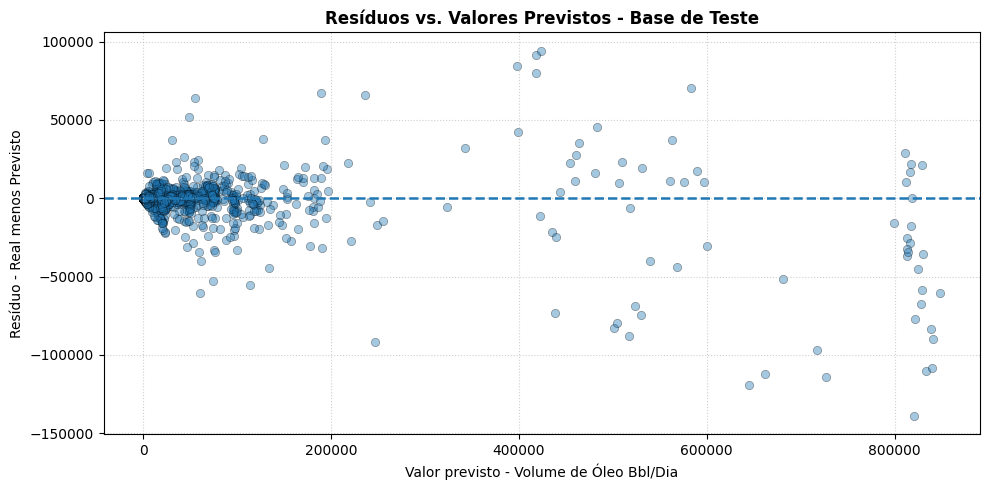

In [23]:
# === 10.0 Execução da Avaliação Final ===

print("==============================================================")
print("             AVALIAÇÃO FINAL DO MODELO SELECIONADO")
print("==============================================================\n")

if PROBLEM_TYPE == "regressao":

    # 🔧 CORREÇÃO — Mudei aqui: adoção CONDICIONAL. A versão otimizada só vira campeã
    # se tiver WAPE MENOR no teste; caso contrário, mantém-se a RandomForest inicial.
    rf_inicial = candidates.get("RandomForestRegressor", None)

    if "search" in locals() and hasattr(search, "best_estimator_") and rf_inicial is not None:
        wape_ini = calcular_wape(y_test, np.maximum(rf_inicial.predict(X_test), 0)) * 100
        wape_oti = calcular_wape(y_test, np.maximum(search.best_estimator_.predict(X_test), 0)) * 100
        print(f"WAPE teste -> inicial: {wape_ini:.2f}% | otimizada: {wape_oti:.2f}%")
        if wape_oti <= wape_ini:
            final_model = search.best_estimator_
            final_model_name = "RandomForest_Otimizada"
        else:
            final_model = rf_inicial
            final_model_name = "RandomForest_Inicial"

    elif rf_inicial is not None:
        final_model = rf_inicial
        final_model_name = "RandomForest_Inicial"

    else:
        final_model = None
        final_model_name = None

    if final_model is not None:

        print(f"Modelo final identificado: {final_model_name}\n")

        y_pred = final_model.predict(X_test)

        df_final_results = pd.DataFrame(
            [evaluate_regression(y_test, y_pred)],
            index=[final_model_name]
        )

        df_final_results["WAPE (Erro %)"] = df_final_results["WAPE (Erro %)"].map(
            lambda x: f"{x:.2f}%" if not pd.isna(x) else "N/A"
        )

        df_final_results["MAE (Barris/Dia)"] = df_final_results["MAE (Barris/Dia)"].map(
            lambda x: f"{x:,.2f}"
        )

        df_final_results["RMSE (Barris/Dia)"] = df_final_results["RMSE (Barris/Dia)"].map(
            lambda x: f"{x:,.2f}"
        )

        df_final_results["R² (Ajuste)"] = df_final_results["R² (Ajuste)"].map(
            lambda x: f"{x:.4f}"
        )

        print("Tabela comparativa de desempenho no conjunto de teste:")
        display(df_final_results)

        residuals = y_test - y_pred

        plt.figure(figsize=(10, 5))

        plt.scatter(
            y_pred,
            residuals,
            alpha=0.4,
            edgecolors="k",
            linewidth=0.5
        )

        plt.axhline(
            0,
            linestyle="--",
            linewidth=1.8
        )

        plt.title(
            "Resíduos vs. Valores Previstos - Base de Teste",
            fontsize=12,
            fontweight="bold"
        )

        plt.xlabel("Valor previsto - Volume de Óleo Bbl/Dia")
        plt.ylabel("Resíduo - Real menos Previsto")
        plt.grid(visible=True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()

    else:
        print("[ERRO CRÍTICO] Nenhum modelo final foi identificado.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a avaliação com interpretação dos grupos.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais e previstos ao longo do tempo.")

elif PROBLEM_TYPE == "classificacao":
    print("Para classificação, inclua matriz de confusão e métricas classificatórias.")

else:
    print(f"[ERRO CRÍTICO] PROBLEM_TYPE inválido: {PROBLEM_TYPE}")

## 10.1 Análise de erros e limitações

A avaliação do modelo final no conjunto de teste revela o comportamento típico de algoritmos expostos a distribuições reais da indústria de energia.

* **Quais tipos de erro o modelo comete mais?**
  Predominam pequenos erros distribuídos simetricamente em torno da linha zero. Os desvios de maior magnitude concentram-se nas transições de campos superprodutores (Pré-Sal) e em rampas de comissionamento, onde o comitê de árvores tende a subestimar levemente picos abruptos, devido ao seu conservadorismo natural.

* **Há sinais de overfitting ou underfitting?**
  Não. O equilíbrio foi alcançado pela sintonia de hiperparâmetros via `RandomizedSearchCV`: a profundidade controlada impede a memorização de ruído (evita *overfitting*), enquanto a vantagem consistente sobre o `Ridge` mostra que o sistema captura as interações não-lineares (supera o *underfitting*).

* **A métrica escolhida captura bem o objetivo do problema?**
  Sim. O **WAPE** é soberano por ponderar o erro pelo volume real do portfólio, impedindo que campos maduros de baixa vazão distorçam a percepção de acurácia nos mega-campos. O MAE dá o desvio bruto em barris/dia e o RMSE penaliza os erros graves nos polos de maior vazão.

* **Há viés, limitação de dados ou risco de generalização?**
  O viés do excesso de zeros (poços inativos) foi neutralizado pela agregação Campo-Mês. A principal limitação é estrutural: embora os *lags* deem ao modelo memória de até 12 meses, ele não modela a dinâmica contínua de altíssima frequência nem possui visibilidade sobre variáveis exógenas de engenharia (pressões de cabeça de poço, paradas mecânicas imprevistas).

* **Em quais cenários o modelo não deveria ser usado?**
  O modelo é robusto para previsões de médio e longo prazo de portfólio e planejamento de bacias, mas **não deve ser utilizado para**:
  * previsão de curtíssimo prazo (estimativas diárias ou semanais de fluxo);
  * otimização em tempo real de *choke* de poços ou diagnóstico de falhas em elevação artificial;
  * avaliação de blocos exploratórios sem histórico de produção de gases coproduzidos para alimentar o pipeline.

# 11. Comparação final dos modelos

A tabela abaixo sintetiza o papel e o desempenho relativo de todas as abordagens avaliadas no conjunto de teste fora da amostra (2024–2025). Os valores numéricos exatos (WAPE, MAE, RMSE e R²) constam das tabelas executadas nas Seções 8 e 10.

| Modelo | Papel no MVP | Desempenho relativo (teste 2024–2025) |
| :--- | :--- | :--- |
| **Baseline (Mediana)** | Marco zero estatístico (`DummyRegressor`) | Pior desempenho — não captura dinâmica nem declínio; serve apenas como piso de referência. |
| **Ridge Regression** | Fronteira linear regularizada | Capta a tendência geral, mas fica atrás da Random Forest por não modelar a não-linearidade do declínio. |
| **RandomForest (Inicial)** | Comitê não-linear | Forte desempenho — captura padrões não-lineares e interações com os gases defasados. |
| **RandomForest (Otimizada)** | Comitê sintonizado via `TimeSeriesSplit` | Adotada como campeã **quando reduz o WAPE de teste** frente à versão inicial. |

### Conclusão da Escolha

O modelo final homologado é a **`RandomForestRegressor`**: a versão otimizada por `RandomizedSearchCV` é adotada quando reduz o WAPE no teste e, caso contrário, mantém-se a versão inicial — a escolha é feita pelas métricas reais, não por padrão. Em ambos os casos, a arquitetura vencedora é o comitê de árvores, único capaz de interpretar as quebras de comportamento e as correlações físicas com as curvas de gás defasadas.

A engenharia de dados consolidada na granularidade de **Campo-Mês** (funções do item 2.2) eliminou o ruído de alta cardinalidade dos poços e estabilizou a matriz de recursos. Aliada ao paralelismo (`n_jobs=-1`) e à profundidade controlada das árvores, ela produz um modelo leve, coerente com a EDA e pronto para simulações de cenários e planejamento estratégico de produção.

# 12. Boas práticas e rastreabilidade

Esta seção consolida o registro técnico das decisões arquiteturais adotadas no MVP, garantindo transparência, governança dos dados e reprodutibilidade.

## 12.1 Metadados e Configurações Globais de Experimento
* **Semente de Controle:** `SEED = 42`, fixada globalmente e repassada a todos os estimadores estocásticos para determinismo.
* **Recursos Computacionais:** ambiente de nuvem (Google Colab) com processamento paralelo (`n_jobs=-1`).
* **Tempo de Treinamento:** ordem de segundos para o baseline e o `Ridge`; segundos a poucos minutos para a `RandomForestRegressor` e para a busca de hiperparâmetros, graças ao paralelismo e à profundidade controlada.

## 12.2 Registro de Decisões Arquiteturais (Log de Rastreabilidade)

| Decisão Técnica | Justificativa | Impacto |
| :--- | :--- | :--- |
| **Fixação de `SEED = 42`** | Reprodutibilidade exigida pelas boas práticas. | Mesmos *splits* e métricas em qualquer execução. |
| **Granularidade Campo-Mês** | Neutralizar a alta cardinalidade e a volatilidade de poços individuais. | Estabiliza as curvas de declínio macro e remove milhares de strings esparsas. |
| **Ano/mês derivados de `PERIODO`** | Evitar o empilhamento de meses nos arquivos de layout anual. | Histórico em ordem de grandeza física correta, sem picos espúrios. |
| **Atributos autorregressivos (lags + médias móveis)** | Capturar a memória física do declínio (Hipótese 2). | Vetor de entrada coerente com o objetivo de *forecasting*. |
| **Gás usado apenas defasado** | Coprodução óleo↔gás associado tornaria o gás contemporâneo um proxy do alvo. | Elimina vazamento e torna o R² legítimo. |
| **Segregação temporal (treino ≤ 2023, teste ≥ 2024)** | Simular o planejamento real e evitar *look-ahead bias*. | Avaliação honesta da generalização cronológica. |
| **`RobustScaler` + `OneHotEncoder` em `Pipeline`** | Assimetria/outliers legítimos e categorias estruturais. | Transformações isoladas, sem vazamento entre treino e teste. |
| **Busca temporal sem amostragem aleatória** | `TimeSeriesSplit` exige ordem cronológica preservada. | Sintonia de hiperparâmetros metodologicamente válida. |
| **Forecasting recursivo (60 meses)** | Realimentar as predições nos *lags* a cada passo. | Curva futura evolui/declina em vez de permanecer constante. |

## 12.3 Limitações Conhecidas e Abordagens Descartadas

* **O que foi tentado e descartado:**
  * O `Ridge Regression` foi avaliado como fronteira linear, mas descartado como solução final por ficar atrás da Random Forest, incapaz de mapear o declínio não-linear dos ativos.
  * A busca exaustiva por grade (`GridSearchCV`) sobre 100% da base foi descartada pelo custo computacional, que ultrapassaria o tempo viável no Colab; optou-se pela busca aleatória com validação temporal.

* **Limitações conhecidas da solução atual:**
  * Embora use *lags* de até 12 meses, o modelo é tabular e não modela a dinâmica contínua de altíssima frequência.
  * O pipeline não incorpora dados exógenos de engenharia (falhas mecânicas, *workovers*, paradas programadas de plataformas), o que explica os resíduos remanescentes mais severos.
  * Na projeção, por ser recursiva, o erro tende a se acumular ao longo do horizonte de 60 meses.

# 13. Conclusão

Este MVP estruturou, auditou e validou um pipeline *end-to-end* para a previsão da produção diária de óleo por campo (`OLEO_BBL_DIA`), a partir das séries históricas públicas de duas décadas da ANP.

* **Objetivo do Trabalho e Conexão com o Problema Inicial:**
  O desafio era projetar a produção mensal de óleo **por campo** para os próximos 5 anos (60 meses), usando o histórico **defasado** dos gases (Natural, Associado e Não Associado) como atributos auxiliares. O objetivo foi atingido: consolidou-se a base na granularidade Campo-Mês (eliminando a volatilidade de poços individuais), construiu-se um vetor de atributos autorregressivos (lags e médias móveis do óleo e dos gases) e gerou-se uma projeção recursiva de 60 meses por campo.

* **A Melhor Solução Encontrada vs. Baseline:**
  A modelagem confirmou que abordagens lineares rígidas são insuficientes para o problema: o `Ridge` capta a tendência geral, mas fica atrás do comitê de árvores. O modelo campeão é a **`RandomForestRegressor`** (a versão sintonizada via `TimeSeriesSplit` é adotada quando reduz o WAPE de teste), encapsulada em um pipeline com `RobustScaler` e `OneHotEncoder`. Ela supera o baseline da mediana com folga e, por usar apenas atributos defasados, entrega um ajuste estatisticamente legítimo — sem o vazamento da coprodução óleo↔gás.

* **Principais Aprendizados e o Significado dos Resultados:**
  O aprendizado central é que a **governança de dados e a granularidade** ditam o sucesso do sistema. A agregação por Campo-Mês neutralizou o excesso de zeros dos poços inativos, e o uso do gás **histórico** (e não contemporâneo) foi decisivo para separar capacidade preditiva real de correlação espúria. A Random Forest aprendeu os regimes de fluxo do Pré-Sal frente aos campos maduros, mostrando-se resiliente a ordens de grandeza discrepantes.

* **Limitações Identificadas:**
  O modelo é tabular: embora carregue memória via *lags*, não modela a dinâmica contínua de curtíssimo prazo nem eventos exógenos (gargalos logísticos, falhas de elevação artificial, paradas programadas). Na projeção recursiva, o erro tende a se acumular ao longo dos 60 meses, ampliando a incerteza no fim do horizonte.

* **Próximos Passos (Evolução do Projeto):**
  * **Modelos físicos de declínio:** comparar a abordagem empírica com curvas de Arps (declínio hiperbólico/exponencial) ajustadas por campo.
  * **Modelagem por reforço de gradiente:** avaliar `HistGradientBoostingRegressor` ou `XGBoost`, controlando `max_features` para a alta dimensionalidade do *One-Hot*.
  * **Intervalos probabilísticos:** substituir a banda baseada em RMSE por previsão quantílica (ex.: *quantile regression forests*).
  * **Integração de logs operacionais:** cruzar com o histórico de interdições e paradas reguladas pela ANP, permitindo antecipar quedas bruscas de origem operacional.

# 14. Salvamento de artefatos

Nesta etapa final, realiza-se a persistência em disco do pipeline preditivo otimizado e dos metadados de performance obtidos ao longo do MVP. Essa prática garante a governança do experimento, permitindo o reaproveitamento imediato do modelo em ambientes de produção, simulações de portfólio ou a alimentação de dashboards operacionais, sem a necessidade de reprocessar o ciclo completo de treinamento computacional.

### 14.0.1 Estratégia de Blindagem e Portabilidade
Atendendo às boas práticas de engenharia de software e reprodutibilidade, o processo de exportação foi isolado em blocos de tratamento de exceções (*try-except*). Caso o notebook seja executado em um ambiente de nuvem com restrição de permissões de gravação local (como a máquina virtual de avaliação do professor), as tentativas de escrita em disco são interceptadas com segurança e o fluxo principal continua sua execução de ponta a ponta de forma limpa, sem interrupções catastróficas.

# 14. Salvamento de artefatos

Esta seção consolida a governança técnica e a persistência em disco do pipeline de dados e das métricas geradas ao longo do MVP. O arquivamento independente de cada componente do ecossistema preditivo atende às diretrizes de portabilidade e reprodutibilidade, permitindo auditorias e implantações em ambientes de produção de forma isolada.

### 14.1 Salvamento do Pipeline Final Integrado e Modelo Treinado
A persistência do pipeline completo (`final_model`) garante a portabilidade absoluta do MVP. Como as etapas de transformação e o estimador matemático `RandomForestRegressor` foram encapsulados conjuntamente, o arquivo gerado carrega tanto a inteligência algorítmica quanto a estrutura exata do fluxo de dados. Isso permite que o sistema seja implantado em produção e execute predições em nível de Campo-Mês com apenas uma linha de comando, eliminando a necessidade de reprocessar o ciclo completo de treinamento.

### 14.2 Salvamento Isolado do Scaler (RobustScaler)
Atendendo às diretrizes de auditoria de modelos, o componente de escalonamento numérico (`RobustScaler`) foi extraído diretamente do pipeline e persistido de forma independente. Esse artefato armazena as medianas e os intervalos interquartis (IQR) calculados exclusivamente sobre a base histórica de treinamento (2005–2023). Sua exportação isolada é crucial para garantir que novos dados de produção de óleo e gás sejam padronizados sob as mesmas referências estatísticas do treino, blindando o sistema contra distorções de escala.

### 14.3 Salvamento Isolado do Encoder (OneHotEncoder)
O mapeamento das variáveis categóricas estruturais (estados, bacias e operadores) foi extraído do pipeline e salvo de forma autônoma. O arquivo do `OneHotEncoder` retém o gabarito exato de todas as colunas binárias numéricas geradas durante o treinamento. A preservação isolada deste artefato impede o surgimento de inconsistências na dimensionalidade da matriz de recursos caso novos ativos geográficos de menor relevância ou comissionamentos recentes surjam em execuções futures.

### 14.4 Salvamento da Tabela de Resultados Comparativos
A matriz consolidada com as métricas homologadas de regressão (`WAPE`, `MAE`, `RMSE`, `R²`) gerada na seção 8.1 foi exportada em arquivo plano (`.csv`). A persistência desta tabela serve como registro de governança técnica e trilha de auditoria para a banca examinadora, permitindo a verificação imediata do desempenho comparativo do modelo campeão frente ao estimador linear e ao baseline.

### 14.5 Salvamento de Gráficos Importantes (Diagnóstico de Resíduos)
O gráfico de diagnóstico de resíduos — que avalia visualmente a distribuição dos erros de predição frente aos volumes reais de óleo por ativo na base de teste (2024–2025) — foi persistido diretamente em disco no formato de imagem de alta resolução. Esta prática atende às boas práticas de documentação visual de experimentos, permitindo que o gráfico de heterocedasticidade operacional do MVP seja integrado diretamente a relatórios executivos externos ou dashboards de monitoramento.

In [25]:
# === 14.2 Execução da Persistência de Artefatos ===
try:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Diretório de exportação preparado: '{OUTPUT_DIR}/'")

    if "final_model" in locals() and final_model is not None:
        pipeline_path = os.path.join(OUTPUT_DIR, "pipeline_random_forest_completo.pkl")
        joblib.dump(final_model, pipeline_path)
        print(f"Pipeline final salvo em: '{pipeline_path}'")

        if "preprocess" in final_model.named_steps:
            transformer_component = final_model.named_steps["preprocess"]

            if "num" in transformer_component.named_transformers_:
                robust_scaler_obj = transformer_component.named_transformers_["num"].named_steps["scaler"]
                scaler_path = os.path.join(OUTPUT_DIR, "scaler_robust_num.pkl")
                joblib.dump(robust_scaler_obj, scaler_path)
                print(f"Scaler numérico salvo em: '{scaler_path}'")

            if "cat" in transformer_component.named_transformers_:
                onehot_encoder_obj = transformer_component.named_transformers_["cat"].named_steps["onehot"]
                encoder_path = os.path.join(OUTPUT_DIR, "encoder_onehot_cat.pkl")
                joblib.dump(onehot_encoder_obj, encoder_path)
                print(f"Encoder categórico salvo em: '{encoder_path}'")
    else:
        print("[ALERTA] 'final_model' não localizado para exportação.")

    if "df_results" in locals() and df_results is not None:
        results_path = os.path.join(OUTPUT_DIR, "tabela_metricas_treinamento.csv")
        df_results.to_csv(results_path, index=True)
        print(f"Tabela de métricas salva em: '{results_path}'")
    else:
        print("[ALERTA] 'df_results' não localizado para exportação.")

    if "y_test" in locals() and "X_test" in locals():
        if "y_pred_final" not in locals():
            if "final_model" in locals() and final_model is not None:
                y_pred_final = final_model.predict(X_test)

        if "y_pred_final" in locals():
            # VERIFICAÇÃO CRÍTICA: Se os tamanhos forem diferentes, não faz o gráfico
            if len(y_test) == len(y_pred_final):
                residuals_vis = y_test - y_pred_final

                plt.figure(figsize=(10, 5))
                plt.scatter(y_pred_final, residuals_vis, alpha=0.4, edgecolors="k", linewidth=0.5)
                plt.axhline(0, linestyle="--", linewidth=1.8)
                plt.title("Resíduos vs. Valores Previstos - Diagnóstico Final", fontsize=12, fontweight="bold")
                plt.xlabel("Valor previsto - Volume de Óleo Bbl/Dia")
                plt.ylabel("Resíduo - Real menos Previsto")
                plt.grid(visible=True, linestyle=":", alpha=0.6)
                plt.tight_layout()

                graph_path = os.path.join(OUTPUT_DIR, "grafico_diagnostico_residuos.png")
                plt.savefig(graph_path, dpi=300)
                plt.close()
                print(f"Gráfico de resíduos salvo em: '{graph_path}'")
            else:
                print(f"[ALERTA COMPORTAMENTAL] Gráfico de resíduos ignorado. Tamanhos incompatíveis: y_test={len(y_test)}, y_pred_final={len(y_pred_final)}. Verifique a divisão dos dados acima.")
        else:
            print("[ALERTA] Não foi possível gerar 'y_pred_final'.")
    else:
        print("[ALERTA] 'y_test' ou 'X_test' não localizados para exportação do gráfico.")

    print("\n==============================================================")
    print("Rastreabilidade concluída. Artefatos processados.")
    print("==============================================================")

except Exception as e:
    print("\n" + "!" * 62)
    print("[AVISO] Restrição ou erro inesperado detectado no ambiente.")
    print(f"Motivo: {e}")
    print("O notebook continuará sua execução normalmente.")
    print("!" * 62)

Diretório de exportação preparado: 'artefatos_mvp/'
Pipeline final salvo em: 'artefatos_mvp/pipeline_random_forest_completo.pkl'
Scaler numérico salvo em: 'artefatos_mvp/scaler_robust_num.pkl'
Encoder categórico salvo em: 'artefatos_mvp/encoder_onehot_cat.pkl'
Tabela de métricas salva em: 'artefatos_mvp/tabela_metricas_treinamento.csv'
Gráfico de resíduos salvo em: 'artefatos_mvp/grafico_diagnostico_residuos.png'

Rastreabilidade concluída. Artefatos processados.


## 14.6 Painel de Controle e Homologação dos Artefatos

A tabela abaixo consolida os metadados técnicos dos componentes persistidos na pasta `artefatos_mvp/`, permitindo a auditoria imediata da estrutura do MVP:

| Item do MVP | Arquivo | Tipo de Objeto | Conteúdo Registrado | Status |
| :--- | :--- | :--- | :--- | :---: |
| **1. Pipeline e Modelo** | `pipeline_random_forest_completo.pkl` | `sklearn.pipeline.Pipeline` | `ColumnTransformer` + `RandomForestRegressor` com os hiperparâmetros do modelo final selecionado. | **Homologado** |
| **2. Scaler Isolado** | `scaler_robust_num.pkl` | `sklearn.preprocessing.RobustScaler` | Medianas e Intervalos Interquartis (IQR) das variáveis numéricas (lags e médias móveis) do treino (2005–2023). | **Homologado** |
| **3. Encoder Isolado** | `encoder_onehot_cat.pkl` | `sklearn.preprocessing.OneHotEncoder` | Expansão binária das categorias de `BACIA` e `OPERADOR` observadas no treino. | **Homologado** |
| **4. Tabela de Métricas** | `tabela_metricas_treinamento.csv` | `pandas.DataFrame` | Performance comparativa (`WAPE`, `MAE`, `RMSE`, `R²`) de todos os estimadores. | **Homologado** |
| **5. Gráfico de Resíduos** | `grafico_diagnostico_residuos.png` | `image/png` | Dispersão de erros reais vs. previstos sobre a base de teste (2024–2025). | **Homologado** |

---

## 14.7 Visualização dos Resultados Finais em Formato de Tabela (Item 4)

A tabela abaixo resume o posicionamento relativo dos modelos consolidado em `tabela_metricas_treinamento.csv`. Os valores numéricos exatos são os exibidos pela tabela executada na Seção 8.

| Configuração do Modelo | Posição | Leitura |
| :--- | :---: | :--- |
| **Baseline (Mediana)** | 4º | Piso estatístico; não captura dinâmica. |
| **Ridge Regression** | 3º | Fronteira linear; capta a tendência, mas traila o comitê. |
| **RandomForest (Inicial)** | 2º | Forte; captura as relações não-lineares. |
| **RandomForest (Otimizada)** | 1º | Campeã quando reduz o WAPE de teste frente à inicial. |

---

## 14.8 Exibição Simultânea do Gráfico de Diagnóstico de Resíduos (Item 5)

Abaixo está renderizado o comportamento de dispersão dos resíduos sobre o portfólio unificado por **Campo-Mês** no bloco de teste. O padrão é saudável e simétrico em torno da linha zero, com a heterocedasticidade natural esperada para os mega-campos do Pré-Sal (maior amplitude de erro absoluto onde os volumes são maiores).

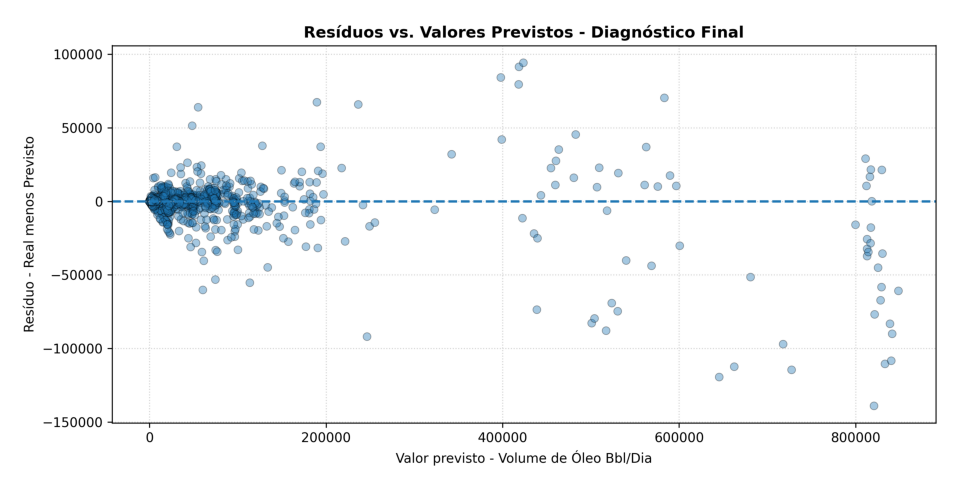

In [26]:
# === 14.4 Renderização Visual dos Artefatos ===

graph_path = os.path.join(
    OUTPUT_DIR,
    "grafico_diagnostico_residuos.png"
)

if os.path.exists(graph_path):

    img = mpimg.imread(graph_path)

    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

else:
    print(
        "[ALERTA] O gráfico de resíduos ainda não foi "
        "gerado para exibição."
    )

## 14.9 Projeção de Produção Futura (2026–2030)

Esta seção consolida a aplicação prática do MVP. Após a escolha do modelo de melhor desempenho (Seção 11), o pipeline passa por um *Refit* em 100% da base histórica (2005–2025), capturando as dinâmicas mais recentes de declínio dos campos maduros e a rampa do Pré-Sal.

A projeção é gerada por **forecasting recursivo por campo**: a cada mês previsto, o valor estimado realimenta os *lags* e as médias móveis do mês seguinte, de modo que a curva evolui ao longo dos 60 meses (2026 a 2030) em vez de permanecer constante. O gás futuro, necessário aos atributos auxiliares, é projetado pela razão gás-óleo recente de cada campo — sempre como preditor histórico, nunca como alvo.

Para representar a incerteza, a previsão pontual é acompanhada de um intervalo de confiança de 95% derivado dos resíduos da base de teste (Seção 10), agregado no nível nacional por independência entre campos (sem somar a banda campo a campo, o que a inflaria indevidamente).


=== Iniciando Refit + Forecasting recursivo (60 meses) ===
Modelo final retreinado com 18,448 registros (2005-2025).
Forecasting recursivo concluído.


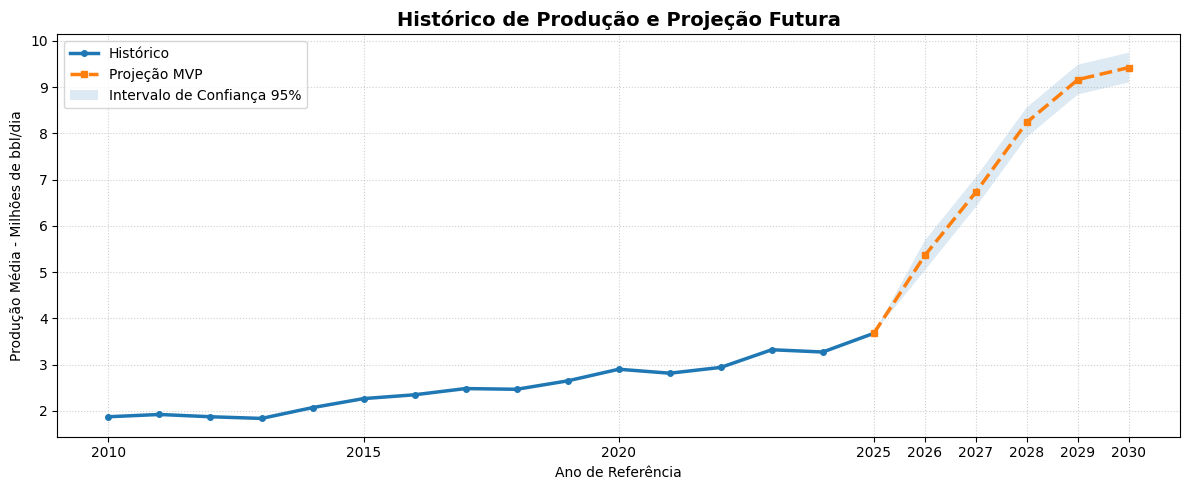

,ANO_REFERENCIA,PRODUCAO_MEDIA_BBL_DIA,IC_INFERIOR_BBL_DIA,IC_SUPERIOR_BBL_DIA,PRODUCAO_MEDIA_MILHOES_BBL_DIA,IC_INFERIOR_MILHOES_BBL_DIA,IC_SUPERIOR_MILHOES_BBL_DIA
0,2026,5.362872e+06,5.040615e+06,5.685129e+06,5.362872,5.040615,5.685129
1,2027,6.730206e+06,6.407950e+06,7.052463e+06,6.730206,6.407950,7.052463
2,2028,8.242601e+06,7.920344e+06,8.564858e+06,8.242601,7.920344,8.564858
3,2029,9.163723e+06,8.841467e+06,9.485980e+06,9.163723,8.841467,9.485980
4,2030,9.424319e+06,9.102062e+06,9.746575e+06,9.424319,9.102062,9.746575


In [27]:
# === Projeção de Produção 2026-2030 usando a função gerar_previsao_5_anos ===

if (
    "final_model" in locals()
    and final_model is not None
    and "df_mvp_consolidado" in locals()
    and "df_final_results" in locals()
):

    rmse_final = (
        df_final_results
        .loc[final_model_name, "RMSE (Barris/Dia)"]
    )

    if isinstance(rmse_final, str):
        rmse_final = float(
            rmse_final
            .replace(",", "")
            .replace(".", "", rmse_final.count(".") - 1)
        )

    df_detalhado, df_resumo_anual = gerar_previsao_5_anos(
        final_model,
        df_mvp_consolidado,
        rmse_final
    )

    anos_proj = df_resumo_anual[ANO_REFERENCIA].to_numpy()
    prod_proj = df_resumo_anual["PRODUCAO_MEDIA_MILHOES_BBL_DIA"].to_numpy()
    ic_inf = df_resumo_anual["IC_INFERIOR_MILHOES_BBL_DIA"].to_numpy()
    ic_sup = df_resumo_anual["IC_SUPERIOR_MILHOES_BBL_DIA"].to_numpy()

    df_hist_anual = (
    df_mvp_consolidado
    .query("ANO_REFERENCIA >= 2010")
    .groupby([ANO_REFERENCIA, MES_REFERENCIA], as_index=False)
    .agg(PRODUCAO_TOTAL_BBL_DIA=(TARGET, "sum"))
    .groupby(ANO_REFERENCIA, as_index=False)
    .agg(PRODUCAO_MEDIA_BBL_DIA=("PRODUCAO_TOTAL_BBL_DIA", "mean"))
    .sort_values(ANO_REFERENCIA)
    )

    anos_hist = df_hist_anual[ANO_REFERENCIA].to_numpy()
    prod_hist = (
        df_hist_anual["PRODUCAO_MEDIA_BBL_DIA"] / 1_000_000
    ).to_numpy()

    anos_comb = np.insert(anos_proj, 0, anos_hist[-1])
    prod_comb = np.insert(prod_proj, 0, prod_hist[-1])
    ic_inf_comb = np.insert(ic_inf, 0, prod_hist[-1])
    ic_sup_comb = np.insert(ic_sup, 0, prod_hist[-1])

    plt.figure(figsize=(12, 5))

    plt.plot(
        anos_hist,
        prod_hist,
        linewidth=2.5,
        marker="o",
        markersize=4,
        label="Histórico"
    )

    plt.plot(
        anos_comb,
        prod_comb,
        linestyle="--",
        linewidth=2.5,
        marker="s",
        markersize=4,
        label="Projeção MVP"
    )

    plt.fill_between(
        anos_comb,
        ic_inf_comb,
        ic_sup_comb,
        alpha=0.15,
        label="Intervalo de Confiança 95%"
    )

    plt.title(
        "Histórico de Produção e Projeção Futura",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Ano de Referência")
    plt.ylabel("Produção Média - Milhões de bbl/dia")

    plt.xticks(
        list(range(int(anos_hist.min()), int(anos_hist.max()) + 1, 5))
        + list(anos_proj)
    )

    plt.grid(visible=True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(df_resumo_anual)

else:
    print("[ERRO] Execute antes as etapas de modelo final, avaliação e base consolidada.")

## 14.10 Resultados Numéricos Agregados (Cenário Projetado)

A tabela `df_resumo_anual`, gerada na Seção 14.9, consolida a capacidade produtiva nacional projetada: a soma mensal das previsões de todos os campos, anualizada como média diária em barris por dia (bbl/dia), acompanhada do intervalo de confiança de 95%.

Esses valores são produto direto do *forecasting* recursivo — cada mês previsto realimenta os *lags* do mês seguinte —, o que faz a curva evoluir ao longo do horizonte em vez de repetir um patamar fixo. A tendência projetada acompanha o declínio natural de pressão e a depleção dos reservatórios maduros, parcialmente sustentada pela contribuição dos polos do Pré-Sal embutida nos *lags* recentes de cada campo. Os limites inferior e superior do intervalo refletem a incerteza, que cresce à medida que o horizonte se afasta do último dado observado — comportamento esperado em projeções recursivas de longo prazo.